# 2026 CITS4012 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

**Group 69 · Dataset: PIQA (Physical Interaction QA) · Main model: DACT (Difference-Aware Contrastive Transformer), trained from scratch.**

### How to run (clean Google Colab)
1. `Runtime → Change runtime type → GPU` (any GPU works; we used an A100/L4 on Colab Pro, bf16 mixed precision is enabled automatically).
2. Put the provided data zip at **`MyDrive/Group69/PIQA.zip`** (contains `train.jsonl`, `train-labels.lst`, `test.jsonl`, `test-labels.lst`). The first data cell mounts Google Drive and extracts only these four files. To use another location change `Config.drive_zip`.
3. `Runtime → Run all`. No extra installation is needed: every package used (`torch`, `tokenizers`, `transformers`, `scikit-learn`, `scipy`, `pandas`, `matplotlib`) is pre-installed on Colab; the first code cell prints their versions. The pretrained baselines (B3/B4) download `FacebookAI/roberta-base` and `Qwen/Qwen2.5-1.5B` from the Hugging Face Hub.

### Notes for the marker
* **Data usage.** No external data. The official PIQA training file is split 90/10 (stratified, seed 42) into *train* / *validation*. **All design decisions, hyper-parameter selection, early stopping and ablation comparisons use the validation split only.** The *test* split is touched only in the clearly marked *Final test evaluation* part of Section 3.
* **From scratch.** DACT and the BiLSTM baseline start from random initialisation; their BPE tokenizer is learned from the training split only. The optional masked-LM warm-up also uses only training-split text. Pretrained models appear only as baselines (B3, B4), and every baseline number is produced by the code in this notebook.
* **Logs.** Every run writes a JSON-lines log (`outputs/logs/*.jsonl`) with the full config and per-epoch metrics, and result summaries to `outputs/results/*.json|csv`. When Google Drive is mounted, the last cell copies `outputs/` (without checkpoints) to `MyDrive/Group69/outputs/`. The outputs saved in this notebook come from one clean top-to-bottom run on a Colab Pro A100 (2026-09-29), executed with the Colab CLI. In that run the four data files were uploaded directly to `/content/data/piqa/`, so the Drive step was skipped. The saved logs, result tables and figures of that run are submitted with this notebook in `outputs/`.
* **Code organisation.** Model classes (`nn.Module`s) are in Section 2 (*Model Implementation*) because the notebook must run top-to-bottom; all remaining code is plain functions. The same code also exists as modules in our repository (`src/`); `python tools/sync_notebook.py` copies them into this notebook so the two cannot drift apart.
* **Revision 2.** (i) Over-long solutions are truncated *around the differing span* instead of keeping the prefix (`Config.diff_aware_truncation`, fixes the cobbler item in Section 3.3); (ii) new ablation *diff-bias prior 0* (`Config.tag_bias_init = 0`) tests whether the initial pooling bias matters; (iii) RoBERTa (B3) is fine-tuned with 3 seeds like the from-scratch models; (iv) an error-overlap analysis compares what DACT and the baselines get right; (v) attention controls separate learned attention from the built-in initial bias. All changes are recorded in `docs/DEVELOPMENT_LOG.md` (section 22).
* **Runtime.** About 60 min on an A100 for everything (DACT grid, 3 seeds of the main model, 8 ablations x 3 seeds, all baselines with 3 RoBERTa seeds). One DACT epoch takes about 4 s.

# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 1.1 Environment check and configuration
All hyper-parameters live in one `Config` dataclass so that every experiment (including ablations) is a documented, logged variation of it.

In [ ]:
import os, sys, platform, importlib
SMOKE = os.environ.get("PIQA_SMOKE") == "1"   # local smoke test only; always False on Colab
for pkg in ["torch", "numpy", "sklearn", "scipy", "pandas", "matplotlib", "tokenizers", "transformers"]:
    print(f"{pkg:13s}", importlib.import_module(pkg).__version__)
import torch
print("python       ", platform.python_version())
print("GPU          ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (switch the runtime to GPU)")

torch         2.11.0+cu128
numpy         2.1.3


sklearn       1.6.1
scipy         1.16.3
pandas        2.2.3
matplotlib    3.10.0
tokenizers    0.23.1


transformers  5.16.1
python        3.13.15
GPU           NVIDIA A100-SXM4-40GB


In [ ]:
"""Global configuration, reproducibility and device helpers."""
import json
import os
import random
import time
from dataclasses import asdict, dataclass, replace

import numpy as np
import torch


@dataclass
class Config:
    # ---- paths ----
    drive_zip: str = "/content/drive/MyDrive/Group69/PIQA.zip"  # Colab location of the provided data
    local_zip_glob: str = "*.zip"                               # fallback when running outside Colab
    data_dir: str = "data/piqa"
    out_dir: str = "outputs"

    # ---- data ----
    seed: int = 42              # seed for the train/validation split (kept fixed across runs)
    val_frac: float = 0.10
    vocab_size: int = 8000
    min_frequency: int = 2
    max_goal_len: int = 40      # BPE tokens
    max_sol_len: int = 96
    diff_aware_truncation: bool = True  # over-long solutions keep the window around the differing span, not the prefix

    # ---- model (DACT) ----
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 4
    d_ff: int = 1024
    dropout: float = 0.2
    attn_dropout: float = 0.1
    max_len: int = 160

    # ---- ablation switches ----
    use_diff_tags: bool = True        # difference-tag embedding
    use_cross_solution: bool = True   # sol1 <-> sol2 contrastive cross-attention
    pool_mode: str = "diff_attn"      # "diff_attn" | "attn" | "mean"
    tag_bias_init: float = 1.0        # initial pooling bias for difference-tagged tokens (0.0 = no built-in prior)
    objective: str = "pairwise"       # "pairwise" (softmax over the two options) | "pointwise" (independent BCE)
    mlm_epochs: int = 0               # in-domain masked-LM warm-up on the training split only

    # ---- optimisation ----
    batch_size: int = 128
    lr: float = 3e-4
    weight_decay: float = 0.05
    epochs: int = 20
    warmup_ratio: float = 0.06
    label_smoothing: float = 0.1
    patience: int = 6
    grad_clip: float = 1.0
    mlm_lr: float = 5e-4
    mlm_prob: float = 0.15
    amp: bool = True
    num_workers: int = 2

    def to_dict(self):
        return asdict(self)

    def but(self, **kw):
        """Return a copy with some fields overridden (used for ablations / seeds)."""
        return replace(self, **kw)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        # TF32 matmuls: large speed-up on Ampere+ GPUs (A100 / L4) with negligible accuracy impact
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def amp_dtype(device):
    """bf16 autocast on GPUs that support it, fp16 on older CUDA GPUs, disabled elsewhere."""
    if device.type != "cuda":
        return None
    return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


class JsonlLogger:
    """Append-only JSON-lines logger so every training/evaluation run leaves a persistent log file."""

    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.path = path

    def log(self, **record):
        record = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), **record}
        with open(self.path, "a") as f:
            f.write(json.dumps(record) + "\n")
        return record

In [ ]:
CFG = Config()
if SMOKE:
    CFG = CFG.but(epochs=1, d_model=64, d_ff=128, n_layers=2, batch_size=32, out_dir="outputs_nbsmoke")
DEVICE = torch.device("cpu") if SMOKE else get_device()
os.makedirs(CFG.out_dir, exist_ok=True)
print("device:", DEVICE, "| autocast dtype:", amp_dtype(DEVICE))

device: cuda | autocast dtype: torch.bfloat16


## 1.2 Loading, splitting and tokenising PIQA
* Each item: a **goal** and two candidate **solutions**; the label says which solution is physically sensible.
* The provided `test` split (1,838 items) is only used at the very end; a stratified 10 % of the training file is held out as the **validation** split.
* **Tokenizer:** byte-pair encoding (8k merges vocabulary) *learned on the training split only*. PIQA has many rare, domain-specific words (tools, materials, recipes), so sub-words avoid a large `[UNK]` rate that a word-level vocabulary would have.
* **Difference tags:** the two solutions of an item are usually near-duplicates. We align their BPE sequences with `difflib.SequenceMatcher` and tag every solution token as *shared* or *different*. These tags are consumed by the model (Section 2).

In [ ]:
"""PIQA loading, train/validation split, BPE tokenizer, difference tags and batching."""
import difflib
import glob
import json
import os
import zipfile

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from torch.utils.data import DataLoader, Dataset


EXPECTED_FILES = ("train.jsonl", "train-labels.lst", "test.jsonl", "test-labels.lst")
SPECIALS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
PAD, UNK, CLS, SEP, MASK = range(len(SPECIALS))

# difference-tag vocabulary
TAG_OTHER, TAG_SHARED, TAG_DIFF = 0, 1, 2   # goal/special tokens, token shared by both solutions, token unique to this solution


# ----------------------------------------------------------------------------------------------
# 1. Locating and extracting the data
# ----------------------------------------------------------------------------------------------
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _find_zip(cfg: Config):
    if _in_colab():
        from google.colab import drive
        if not os.path.isdir("/content/drive/MyDrive"):
            drive.mount("/content/drive")
        if os.path.isfile(cfg.drive_zip):
            return cfg.drive_zip
        raise FileNotFoundError(f"PIQA zip not found at {cfg.drive_zip}. Update Config.drive_zip.")
    for path in [cfg.drive_zip, *sorted(glob.glob(cfg.local_zip_glob))]:
        if os.path.isfile(path) and zipfile.is_zipfile(path):
            with zipfile.ZipFile(path) as zf:
                names = {os.path.basename(n) for n in zf.namelist()}
            if set(EXPECTED_FILES) <= names:
                return path
    raise FileNotFoundError("No zip containing the PIQA files was found.")


def prepare_data(cfg: Config):
    """Extract only the four expected PIQA files into cfg.data_dir (no arbitrary paths are written)."""
    if all(os.path.isfile(os.path.join(cfg.data_dir, f)) for f in EXPECTED_FILES):
        return cfg.data_dir
    zpath = _find_zip(cfg)
    os.makedirs(cfg.data_dir, exist_ok=True)
    with zipfile.ZipFile(zpath) as zf:
        members = {os.path.basename(n): n for n in zf.namelist() if not n.endswith("/")}
        for fname in EXPECTED_FILES:
            with zf.open(members[fname]) as src, open(os.path.join(cfg.data_dir, fname), "wb") as dst:
                dst.write(src.read())
    print(f"Extracted {EXPECTED_FILES} from {zpath} -> {cfg.data_dir}")
    return cfg.data_dir


def load_split(data_dir, split):
    with open(os.path.join(data_dir, f"{split}.jsonl")) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    with open(os.path.join(data_dir, f"{split}-labels.lst")) as f:
        labels = [int(line) for line in f if line.strip()]
    assert len(rows) == len(labels), f"{split}: {len(rows)} rows vs {len(labels)} labels"
    for r, y in zip(rows, labels):
        assert y in (0, 1)
        r["label"] = y
        for k in ("goal", "sol1", "sol2"):
            r[k] = " ".join(str(r[k]).split())  # collapse irregular whitespace
    return rows


def load_piqa(cfg: Config):
    """Returns train / validation (held out from the official training file) / test.

    The test split is returned separately and must only be used for the final evaluation.
    """
    data_dir = prepare_data(cfg)
    full_train = load_split(data_dir, "train")
    test = load_split(data_dir, "test")
    idx = np.arange(len(full_train))
    tr_idx, va_idx = train_test_split(idx, test_size=cfg.val_frac, random_state=cfg.seed,
                                      stratify=[r["label"] for r in full_train])
    train = [full_train[i] for i in tr_idx]
    val = [full_train[i] for i in va_idx]
    return train, val, test


# ----------------------------------------------------------------------------------------------
# 2. Tokenizer (BPE learned from the training split only)
# ----------------------------------------------------------------------------------------------
def train_tokenizer(train_rows, cfg: Config, path=None):
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.Sequence([normalizers.NFKC(), normalizers.Lowercase()])
    tok.pre_tokenizer = pre_tokenizers.Sequence([pre_tokenizers.Whitespace(), pre_tokenizers.Digits(individual_digits=True)])
    trainer = trainers.BpeTrainer(vocab_size=cfg.vocab_size, min_frequency=cfg.min_frequency,
                                  special_tokens=SPECIALS, continuing_subword_prefix="##")
    corpus = (text for r in train_rows for text in (r["goal"], r["sol1"], r["sol2"]))
    tok.train_from_iterator(corpus, trainer=trainer, length=3 * len(train_rows))
    if path:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        tok.save(path)
    return tok


def diff_tags(a, b):
    """Token-level alignment of two solutions: TAG_SHARED where aligned-equal, TAG_DIFF otherwise."""
    ta, tb = [TAG_DIFF] * len(a), [TAG_DIFF] * len(b)
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            ta[i1:i2] = [TAG_SHARED] * (i2 - i1)
            tb[j1:j2] = [TAG_SHARED] * (j2 - j1)
    return ta, tb


def truncate_around_diff(ids, tags, max_len):
    """Keeps a window of max_len tokens that covers as much of the differing span as possible.

    Plain prefix truncation can cut off the only differing words of two near-identical long solutions,
    making the two inputs identical (e.g. test item 1433).
    """
    if len(ids) <= max_len:
        return ids, tags
    diff_pos = [i for i, t in enumerate(tags) if t == TAG_DIFF]
    if not diff_pos:
        return ids[:max_len], tags[:max_len]
    first, last = diff_pos[0], diff_pos[-1]
    start = first - max(0, max_len - (last - first + 1)) // 2   # centre the differing span in the window
    start = min(max(0, start), len(ids) - max_len)
    return ids[start:start + max_len], tags[start:start + max_len]


def encode_example(row, tok, cfg: Config):
    """Encodes one PIQA item into two sequences [CLS] goal [SEP] sol_i [SEP] plus side information."""
    g = tok.encode(row["goal"]).ids[: cfg.max_goal_len]
    s1, s2 = tok.encode(row["sol1"]).ids, tok.encode(row["sol2"]).ids
    if cfg.diff_aware_truncation:
        t1, t2 = diff_tags(s1, s2)   # align the full solutions, then cut both around their differences
        s1, t1 = truncate_around_diff(s1, t1, cfg.max_sol_len)
        s2, t2 = truncate_around_diff(s2, t2, cfg.max_sol_len)
    else:
        s1, s2 = s1[: cfg.max_sol_len], s2[: cfg.max_sol_len]
        t1, t2 = diff_tags(s1, s2)
    out = []
    for s, t in ((s1, t1), (s2, t2)):
        ids = [CLS] + g + [SEP] + s + [SEP]
        seg = [0] * (len(g) + 2) + [1] * (len(s) + 1)
        tags = [TAG_OTHER] * (len(g) + 2) + t + [TAG_OTHER]
        sol = [0] * (len(g) + 2) + [1] * len(s) + [0]   # positions that belong to the solution text
        out.append((ids, seg, tags, sol))
    return out


class PIQADataset(Dataset):
    """Pre-tokenises everything once so the GPU is not starved by Python-side work."""

    def __init__(self, rows, tok, cfg: Config):
        self.rows = rows
        self.items = [encode_example(r, tok, cfg) for r in rows]
        self.labels = [r["label"] for r in rows]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i], self.labels[i], i


def collate(batch):
    """Pads a batch into tensors of shape [B, 2, L]."""
    B = len(batch)
    L = max(len(seq[0]) for item, _, _ in batch for seq in item)
    ids = torch.full((B, 2, L), PAD, dtype=torch.long)
    seg = torch.zeros((B, 2, L), dtype=torch.long)
    tags = torch.zeros((B, 2, L), dtype=torch.long)
    sol = torch.zeros((B, 2, L), dtype=torch.bool)
    for b, (item, _, _) in enumerate(batch):
        for k, (i_, s_, t_, m_) in enumerate(item):
            n = len(i_)
            ids[b, k, :n] = torch.tensor(i_)
            seg[b, k, :n] = torch.tensor(s_)
            tags[b, k, :n] = torch.tensor(t_)
            sol[b, k, :n] = torch.tensor(m_, dtype=torch.bool)
    return {
        "input_ids": ids, "segment": seg, "tags": tags, "sol_mask": sol,
        "attn_mask": ids != PAD,
        "labels": torch.tensor([y for _, y, _ in batch], dtype=torch.long),
        "index": torch.tensor([i for _, _, i in batch], dtype=torch.long),
    }


def make_loader(ds, cfg: Config, shuffle, device):
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle, collate_fn=collate,
                      num_workers=cfg.num_workers if device.type == "cuda" else 0,
                      pin_memory=device.type == "cuda", persistent_workers=False)


def prepare_everything(cfg: Config):
    """Loads the splits, learns the BPE tokenizer on the training split and pre-tokenises every split."""
    train, val, test = load_piqa(cfg)
    tok = train_tokenizer(train, cfg, path=os.path.join(cfg.out_dir, "tokenizer.json"))
    return {"train": train, "val": val, "test": test, "tok": tok, "vocab_size": tok.get_vocab_size(),
            "train_ds": PIQADataset(train, tok, cfg), "val_ds": PIQADataset(val, tok, cfg),
            "test_ds": PIQADataset(test, tok, cfg)}


def token_strings(tok, ids):
    return [tok.id_to_token(int(i)) for i in ids]

In [ ]:
DATA = prepare_everything(CFG)
if SMOKE:
    for split in ("train", "val", "test"):
        ds = DATA[f"{split}_ds"]
        ds.items, ds.labels, ds.rows = ds.items[:256], ds.labels[:256], ds.rows[:256]
        DATA[split] = DATA[split][:256]
print({s: len(DATA[s]) for s in ("train", "val", "test")}, "| vocab size:", DATA["vocab_size"])
print("example:", DATA["train"][0])
enc = DATA["train_ds"].items[0]
print([(t, tag) for t, tag in zip(token_strings(DATA["tok"], enc[0][0]), enc[0][2])])

{'train': 14501, 'val': 1612, 'test': 1838} | vocab size: 8000
example: {'goal': 'how do you scissor something?', 'sol1': 'cut it open.', 'sol2': 'close it.', 'label': 0}
[('[CLS]', 0), ('how', 0), ('do', 0), ('you', 0), ('scissor', 0), ('something', 0), ('?', 0), ('[SEP]', 0), ('cut', 2), ('it', 1), ('open', 2), ('.', 1), ('[SEP]', 0)]


,split,items,label=1 share,goal BPE len (mean),solution BPE len (mean),solution BPE len (p99),differing-token share (median)
0,train,14501,0.500,8.299,21.670,96.0,0.149
1,val,1612,0.500,8.525,22.043,96.0,0.143
2,test,1838,0.505,8.465,21.821,96.0,0.154


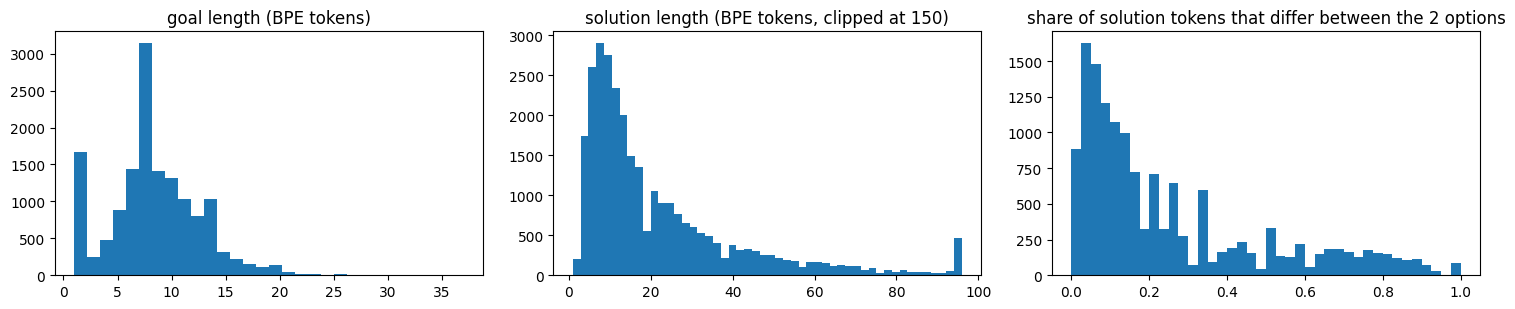

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def split_stats(ds):
    goal_len = [sum(1 for s in it[0][1] if s == 0) - 2 for it in ds.items]
    sol_len = [sum(it[k][3]) for it in ds.items for k in (0, 1)]
    diff_share = [np.mean([t == TAG_DIFF for k in (0, 1) for t, m in zip(it[k][2], it[k][3]) if m] or [0]) for it in ds.items]
    return goal_len, sol_len, diff_share

rows = []
for split in ("train", "val", "test"):
    g, s, d = split_stats(DATA[f"{split}_ds"])
    rows.append({"split": split, "items": len(DATA[f"{split}_ds"]),
                 "label=1 share": np.mean(DATA[f"{split}_ds"].labels),
                 "goal BPE len (mean)": np.mean(g), "solution BPE len (mean)": np.mean(s),
                 "solution BPE len (p99)": np.percentile(s, 99),
                 "differing-token share (median)": np.median(d)})
display(pd.DataFrame(rows).round(3))

g, s, d = split_stats(DATA["train_ds"])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(g, bins=30); ax[0].set_title("goal length (BPE tokens)")
ax[1].hist(np.clip(s, 0, 150), bins=50); ax[1].set_title("solution length (BPE tokens, clipped at 150)")
ax[2].hist(d, bins=40); ax[2].set_title("share of solution tokens that differ between the 2 options")
plt.tight_layout(); plt.show()

**What the statistics imply for the design.**
* Labels are balanced, so **accuracy** is an unbiased metric and chance level is 50 %.
* In the median item only a small fraction of solution tokens differ between the two options (right histogram): the answer depends on a few words (*paper strips* vs *jeans material*, *weld* vs *nail*) placed inside otherwise identical text. A model that encodes each option independently must discover this small signal on its own from only 14.5k training items. DACT therefore (i) marks the differing tokens explicitly, (ii) compares the two options with cross-attention and (iii) biases its pooling towards the differing tokens.
* Solutions are short (p99 of about 100 BPE tokens), so we truncate solutions to 96 and goals to 40 tokens.

# 2. Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 2.1 DACT: Difference-Aware Contrastive Transformer

```
 goal + sol1 ─┐                                     ┌─ diff-guided attention pooling ─┐
              ├─ shared Transformer encoder ─ h1 ─┐ │                                 ├─ scorer → s1 ┐
 tags(sol1)  ─┘   (token+pos+segment+DIFF-TAG)    ├─┤ contrastive cross-solution attn │              ├─ softmax → P(option)
 goal + sol2 ─┐                                   │ │   h_i attends to h_j, fuse      │              │
              ├─ shared Transformer encoder ─ h2 ─┘ │   [h; c; h−c; h⊙c]              ├─ scorer → s2 ┘
 tags(sol2)  ─┘                                     └─────────────────────────────────┘
```

| Component | Standard choice | Our PIQA-specific change | Why |
|---|---|---|---|
| Input embedding | token + position (+ segment) | **+ difference-tag embedding** (goal/special, shared, different) | Tells the encoder from layer 1 where the two options disagree, so it does not have to learn this from 14.5k items |
| Option interaction | options scored independently | **Contrastive cross-solution attention**: each token of option *i* attends to the tokens of option *j* (plus a `[CLS]` sink for "no counterpart"), fused ESIM-style with `[h; c; h−c; h⊙c]` | Physical plausibility is relative ("jar" vs "plate"); the comparison features encode what replaced what |
| Summary vector | `[CLS]` or mean pooling | **Difference-guided additive attention pooling** with a learned bias per tag | Puts the decision on the few decisive tokens while the pooling weights remain interpretable |
| Objective | independent binary classification | **Pairwise softmax** over the two option scores (label smoothing 0.1) | Matches the forced-choice task |
| Encoder | post-LN Transformer | Pre-LN, shared across options, GELU, dropout 0.2 | Stable training from scratch; weight sharing makes the model **permutation-equivariant** (swapping options swaps scores, verified below), so it cannot learn a position bias |
| (optional) warm-up | none | Masked-LM warm-up on training-split text only | Compensates for the small labelled set without external data; kept only if it helps on validation |

Every component can be switched off in `Config`, which is how the ablations in Section 3 are run.

In [ ]:
"""DACT: Difference-Aware Contrastive Transformer for PIQA (trained from scratch).

Pipeline for one PIQA item (goal g, solutions s1, s2):
  1. each option is encoded as [CLS] g [SEP] s_i [SEP] by a shared Transformer encoder whose input embedding
     = token + position + segment + DIFFERENCE TAG (shared-with-other-option / unique-to-this-option);
  2. CONTRASTIVE CROSS-SOLUTION ATTENTION lets every token of s_i attend to the tokens of s_j, and fuses
     [h; c; h-c; h*c] so the representation explicitly encodes how this option differs from its rival;
  3. DIFFERENCE-GUIDED ATTENTION POOLING summarises each option with a learned bias towards differing tokens;
  4. a shared scorer produces one logit per option; the two logits compete in a softmax.
The same weights process both options, so the model is permutation-equivariant in the option order.
"""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    """Multi-head scaled dot-product attention.

    Uses the fused SDPA kernel for speed during training, and an explicit implementation when the attention
    weights are requested for visualisation.
    """

    def __init__(self, d_model, n_heads, attn_dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.p = attn_dropout

    def forward(self, x, kv, key_mask, return_attn=False):
        B, Lq, D = x.shape
        Lk = kv.size(1)
        q = self.q(x).view(B, Lq, self.h, self.dh).transpose(1, 2)
        k = self.k(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        v = self.v(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        mask = key_mask[:, None, None, :]          # True = may attend
        p = self.p if self.training else 0.0
        attn = None
        if return_attn:
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
            scores = scores.masked_fill(~mask, float("-inf"))
            attn = torch.nan_to_num(scores.float().softmax(-1)).to(q.dtype)
            out = F.dropout(attn, p, self.training) @ v
        else:
            out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask, dropout_p=p)
        return self.o(out.transpose(1, 2).reshape(B, Lq, D)), attn


class EncoderLayer(nn.Module):
    """Pre-LayerNorm Transformer encoder block (more stable than post-LN when training from scratch)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.attn_dropout)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Dropout(cfg.dropout),
                                nn.Linear(cfg.d_ff, cfg.d_model))
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, key_mask, return_attn=False):
        a, w = self.attn(self.ln1(x), self.ln1(x), key_mask, return_attn)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x, w


class ContrastiveCrossSolution(nn.Module):
    """Each option's tokens attend to the rival option's solution tokens; ESIM-style comparison fusion."""

    def __init__(self, cfg: Config):
        super().__init__()
        d = cfg.d_model
        self.ln = nn.LayerNorm(d)
        self.attn = MultiHeadAttention(d, cfg.n_heads, cfg.attn_dropout)
        self.fuse = nn.Sequential(nn.Linear(4 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, d))
        self.out_ln = nn.LayerNorm(d)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, h_self, h_other, other_key_mask, return_attn=False):
        q, kv = self.ln(h_self), self.ln(h_other)
        c, w = self.attn(q, kv, other_key_mask, return_attn)
        m = self.fuse(torch.cat([q, c, q - c, q * c], dim=-1))
        return self.out_ln(h_self + self.drop(m)), w


class AttentionPooling(nn.Module):
    """Additive attention pooling over solution tokens.

    mode="diff_attn": score_t = v^T tanh(W h_t) + b[tag_t]  (learned bias per difference tag)
    mode="attn":      same without the tag bias
    mode="mean":      uniform average (ablation)
    """

    def __init__(self, d_model, mode, diff_bias_init=1.0):
        super().__init__()
        self.mode = mode
        self.proj = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, 1, bias=False)
        self.tag_bias = nn.Parameter(torch.tensor([0.0, 0.0, diff_bias_init]))  # other, shared, diff

    def forward(self, h, mask, tags):
        mask = mask.clone()
        mask[~mask.any(-1), 0] = True  # empty solution -> fall back to [CLS]
        if self.mode == "mean":
            w = mask.float() / mask.float().sum(-1, keepdim=True)
        else:
            s = self.v(torch.tanh(self.proj(h))).squeeze(-1).float()
            if self.mode == "diff_attn":
                s = s + self.tag_bias[tags]
            w = s.masked_fill(~mask, float("-inf")).softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return pooled, w


class DACT(nn.Module):
    def __init__(self, cfg: Config, vocab_size):
        super().__init__()
        self.cfg = cfg
        d = cfg.d_model
        self.tok = nn.Embedding(vocab_size, d, padding_idx=PAD)
        self.pos = nn.Embedding(cfg.max_len, d)
        self.seg = nn.Embedding(2, d)
        self.tag = nn.Embedding(3, d) if cfg.use_diff_tags else None
        self.emb_ln = nn.LayerNorm(d)
        self.emb_drop = nn.Dropout(cfg.dropout)
        self.layers = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.n_layers)])
        self.final_ln = nn.LayerNorm(d)
        self.cross = ContrastiveCrossSolution(cfg) if cfg.use_cross_solution else None
        self.pool = AttentionPooling(d, cfg.pool_mode, cfg.tag_bias_init)
        self.scorer = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, 1))
        # masked-LM head (only used for the optional in-domain warm-up), tied to the token embedding
        self.mlm_transform = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.LayerNorm(d))
        self.mlm_bias = nn.Parameter(torch.zeros(vocab_size))
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding) and m.padding_idx is not None:
                with torch.no_grad():
                    m.weight[m.padding_idx].zero_()

    def encode(self, ids, seg, tags, attn_mask, return_attn=False):
        """ids/seg/tags/attn_mask: [N, L] -> hidden states [N, L, d] and per-layer self-attention."""
        L = ids.size(1)
        pos = torch.arange(L, device=ids.device)[None]
        x = self.tok(ids) + self.pos(pos) + self.seg(seg)
        if self.tag is not None:
            x = x + self.tag(tags)
        x = self.emb_drop(self.emb_ln(x))
        attns = []
        for layer in self.layers:
            x, w = layer(x, attn_mask, return_attn)
            attns.append(w)
        return self.final_ln(x), attns

    def forward(self, batch, return_attn=False):
        ids, seg, tags = batch["input_ids"], batch["segment"], batch["tags"]
        attn_mask, sol_mask = batch["attn_mask"], batch["sol_mask"]
        B, _, L = ids.shape
        N = B * 2
        h, self_attn = self.encode(ids.view(N, L), seg.view(N, L), tags.view(N, L), attn_mask.view(N, L),
                                   return_attn)
        h = h.view(B, 2, L, -1)
        out = {}
        if self.cross is not None:
            # keys = the rival's solution tokens plus its [CLS] as a "no match" sink
            key_mask = sol_mask.clone()
            key_mask[:, :, 0] = True
            h1, w12 = self.cross(h[:, 0], h[:, 1], key_mask[:, 1], return_attn)
            h2, w21 = self.cross(h[:, 1], h[:, 0], key_mask[:, 0], return_attn)
            h = torch.stack([h1, h2], dim=1)
            out["cross_attn"] = (w12, w21)
        hf = h.reshape(N, L, -1)
        pooled, pool_w = self.pool(hf, sol_mask.view(N, L), tags.view(N, L))
        feats = torch.cat([pooled, hf[:, 0]], dim=-1)            # pooled solution summary + [CLS]
        out["logits"] = self.scorer(feats).view(B, 2).float()
        out["pool"] = pool_w.view(B, 2, L)
        if return_attn:
            out["self_attn"] = [w.view(B, 2, *w.shape[1:]) for w in self_attn]
        return out

    def mlm_logits(self, ids, seg, tags, attn_mask):
        h, _ = self.encode(ids, seg, tags, attn_mask)
        return self.mlm_transform(h) @ self.tok.weight.T + self.mlm_bias


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 2.2 Baselines
| ID | Baseline | Trained from scratch? | Role |
|---|---|---|---|
| B0 | Majority class | n/a | chance level |
| B1 | TF-IDF (1-2-grams) of *sol2 − sol1* + logistic regression (C tuned on validation) | yes | How far do shallow lexical cues get? |
| B2 | 2-layer BiLSTM + additive attention, same BPE tokenizer | yes | Same budget, recurrent instead of our Transformer design |
| B3 | `roberta-base` fine-tuned with a multiple-choice head | no (pretrained) | Reference for pretrained encoders |
| B4 | `Qwen2.5-1.5B` zero-shot, length-normalised log-likelihood | no (open LLM) | Reference for LLM knowledge without any training |

In [ ]:
"""Baselines. Every number reported for these is produced by running this code (no numbers copied from papers).

B0  majority class
B1  TF-IDF of solution text + logistic regression (tests shallow lexical cues)
B2  BiLSTM + additive attention, trained from scratch with the same tokenizer (non-Transformer comparison)
B3  fine-tuned pretrained encoder (RoBERTa) with a multiple-choice head
B4  zero-shot open LLM (Qwen2.5), length-normalised log-likelihood of each solution
"""
import copy
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import vstack


# ---------------------------------------------------------------- B0
def majority_baseline(train_rows, rows):
    majority = int(np.mean([r["label"] for r in train_rows]) >= 0.5)
    return np.full(len(rows), majority)


# ---------------------------------------------------------------- B1
def tfidf_lr_baseline(train_rows, val_rows, test_rows, Cs=(0.03, 0.1, 0.3, 1.0, 3.0, 10.0)):
    """Feature vector = tfidf(sol2) - tfidf(sol1); trained on both option orders; C picked on validation."""
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True)
    vec.fit([r[k] for r in train_rows for k in ("goal", "sol1", "sol2")])

    def feats(rows):
        return vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])

    Xtr = feats(train_rows)
    ytr = np.array([r["label"] for r in train_rows])
    X_aug, y_aug = vstack([Xtr, -Xtr]), np.concatenate([ytr, 1 - ytr])
    Xva, yva = feats(val_rows), np.array([r["label"] for r in val_rows])
    best = None
    for C in Cs:
        clf = LogisticRegression(C=C, max_iter=2000).fit(X_aug, y_aug)
        acc = float((clf.predict(Xva) == yva).mean())
        if best is None or acc > best[0]:
            best = (acc, C, clf)
    _, C, clf = best
    return {"C": C, "val_pred": clf.predict(Xva), "test_pred": clf.predict(feats(test_rows))}


# ---------------------------------------------------------------- B2
class BiLSTMAttention(nn.Module):
    """Each option ([CLS] goal [SEP] sol [SEP]) -> BiLSTM -> additive attention pooling -> score."""

    def __init__(self, cfg: Config, vocab_size, hidden=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=PAD)
        self.lstm = nn.LSTM(cfg.d_model, hidden, num_layers=2, batch_first=True, bidirectional=True,
                            dropout=cfg.dropout)
        self.att_w = nn.Linear(2 * hidden, 2 * hidden)
        self.att_v = nn.Linear(2 * hidden, 1, bias=False)
        self.drop = nn.Dropout(cfg.dropout)
        self.scorer = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.GELU(), nn.Dropout(cfg.dropout),
                                    nn.Linear(hidden, 1))

    def forward(self, batch, return_attn=False):
        ids, mask = batch["input_ids"], batch["attn_mask"]
        B, _, L = ids.shape
        ids, mask = ids.view(B * 2, L), mask.view(B * 2, L)
        lengths = mask.sum(-1).cpu()
        x = self.drop(self.emb(ids))
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        h, _ = self.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(h, batch_first=True, total_length=L)
        s = self.att_v(torch.tanh(self.att_w(h))).squeeze(-1).float().masked_fill(~mask, float("-inf"))
        w = s.softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return {"logits": self.scorer(self.drop(pooled)).view(B, 2).float(), "pool": w.view(B, 2, L)}


# ---------------------------------------------------------------- B3
def finetune_pretrained(model_name, train_rows, val_rows, test_rows, device, out_dir, epochs=4, lr=1e-5,
                        batch_size=16, max_len=128, seed=42, verbose=True):
    """Fine-tunes a pretrained encoder with a multiple-choice head; model selection on validation only."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer, get_linear_schedule_with_warmup

    torch.manual_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMultipleChoice.from_pretrained(model_name).to(device)
    logger = JsonlLogger(f"{out_dir}/logs/B3_{model_name.split('/')[-1]}_seed{seed}.jsonl")

    def encode(rows):
        goals = [r["goal"] for r in rows for _ in range(2)]
        sols = [r[k] for r in rows for k in ("sol1", "sol2")]
        enc = tok(goals, sols, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
        enc = {k: v.view(len(rows), 2, -1) for k, v in enc.items()}
        return enc, torch.tensor([r["label"] for r in rows])

    def batches(enc, y, shuffle):
        order = torch.randperm(len(y)) if shuffle else torch.arange(len(y))
        for i in range(0, len(y), batch_size):
            idx = order[i:i + batch_size]
            yield {k: v[idx].to(device) for k, v in enc.items()}, y[idx].to(device)

    @torch.no_grad()
    def predict(enc, y):
        model.eval()
        preds = []
        for xb, _ in batches(enc, y, False):
            with autocast_ctx(device):
                preds.append(model(**xb).logits.argmax(-1).cpu())
        return torch.cat(preds).numpy()

    tr, ytr = encode(train_rows)
    va, yva = encode(val_rows)
    te, yte = encode(test_rows)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * ((len(ytr) + batch_size - 1) // batch_size)
    sched = get_linear_schedule_with_warmup(opt, int(0.06 * steps), steps)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    best_acc, best_state = -1.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for xb, yb in batches(tr, ytr, True):
            with autocast_ctx(device):
                loss = F.cross_entropy(model(**xb).logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        val_acc = float((predict(va, yva) == yva.numpy()).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=float(np.mean(losses)), val_acc=val_acc,
                         seconds=round(time.time() - t0, 1))
        if verbose:
            print(f"[B3 {model_name}] ep {epoch} loss {rec['train_loss']:.4f} val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
    model.load_state_dict(best_state)
    out = {"val_pred": predict(va, yva), "test_pred": predict(te, yte), "best_val_acc": best_acc}
    logger.log(event="end", best_val_acc=best_acc)
    del model
    return out


# ---------------------------------------------------------------- B4
@torch.no_grad()
def llm_zero_shot(model_name, rows, device, batch_size=32, verbose=True):
    """Chooses the solution with the higher mean token log-probability given a goal prompt (no training)."""
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tok = AutoTokenizer.from_pretrained(model_name)
    dtype = amp_dtype(device) or torch.float32
    model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype).to(device).eval()
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id

    seqs = []  # (input ids, number of continuation tokens)
    for r in rows:
        prompt = tok(f"Goal: {r['goal']}\nSolution:", add_special_tokens=True).input_ids
        for k in ("sol1", "sol2"):
            cont = tok(" " + r[k], add_special_tokens=False).input_ids[:128]
            seqs.append((prompt + cont, len(cont)))
    scores = []
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i:i + batch_size]
        L = max(len(s) for s, _ in chunk)
        ids = torch.full((len(chunk), L), pad_id, dtype=torch.long)
        cont_mask = torch.zeros((len(chunk), L), dtype=torch.bool)
        attn = torch.zeros((len(chunk), L), dtype=torch.long)
        for j, (s, n) in enumerate(chunk):
            ids[j, :len(s)] = torch.tensor(s)
            attn[j, :len(s)] = 1
            cont_mask[j, len(s) - n:len(s)] = True
        ids, attn, cont_mask = ids.to(device), attn.to(device), cont_mask.to(device)
        logp = model(input_ids=ids, attention_mask=attn).logits.float().log_softmax(-1)
        tok_lp = logp[:, :-1].gather(-1, ids[:, 1:, None]).squeeze(-1)
        m = cont_mask[:, 1:].float()
        scores.append(((tok_lp * m).sum(-1) / m.sum(-1).clamp(min=1)).cpu())
        if verbose and (i // batch_size) % 50 == 0:
            print(f"[B4 {model_name}] {i}/{len(seqs)}")
    scores = torch.cat(scores).view(-1, 2)
    del model
    return scores.argmax(-1).numpy()

## 2.3 Training utilities
AdamW (β₂ = 0.98, no decay on biases/LayerNorm/embeddings), linear warm-up + cosine decay, gradient clipping, bf16 autocast on GPU, early stopping on **validation** accuracy, and a JSON-lines log for every run.

In [ ]:
"""Training loops (QA fine-tuning, optional in-domain MLM warm-up) with mixed precision and JSONL logging."""
import math
import os
import time
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


N_SPECIAL = 5  # ids < 5 are special tokens and are never masked


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def autocast_ctx(device):
    dtype = amp_dtype(device)
    return torch.autocast("cuda", dtype=dtype) if dtype is not None else nullcontext()


def make_optimizer(model, lr, weight_decay):
    """No weight decay on biases, LayerNorm and embedding tables."""
    emb = {id(m.weight) for m in model.modules() if isinstance(m, torch.nn.Embedding)}
    params = [p for p in model.parameters() if p.requires_grad]
    decay = [p for p in params if p.ndim >= 2 and id(p) not in emb]
    no_decay = [p for p in params if p.ndim < 2 or id(p) in emb]
    return torch.optim.AdamW([{"params": decay, "weight_decay": weight_decay},
                              {"params": no_decay, "weight_decay": 0.0}], lr=lr, betas=(0.9, 0.98))


def warmup_cosine(optimizer, total_steps, warmup_ratio):
    warmup = max(1, int(total_steps * warmup_ratio))

    def f(step):
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)


def qa_loss(logits, labels, cfg: Config):
    if cfg.objective == "pairwise":
        return F.cross_entropy(logits, labels, label_smoothing=cfg.label_smoothing)
    target = F.one_hot(labels, 2).float() * (1 - cfg.label_smoothing) + 0.5 * cfg.label_smoothing
    return F.binary_cross_entropy_with_logits(logits, target)


@torch.no_grad()
def predict(model, loader, device):
    """Returns probabilities for option 2 (label 1), predictions and gold labels, ordered by dataset index."""
    model.eval()
    logits, labels, index = [], [], []
    for batch in loader:
        batch = to_device(batch, device)
        with autocast_ctx(device):
            out = model(batch)
        logits.append(out["logits"].float().cpu())
        labels.append(batch["labels"].cpu())
        index.append(batch["index"].cpu())
    logits, labels, index = torch.cat(logits), torch.cat(labels), torch.cat(index)
    order = index.argsort()
    logits, labels = logits[order], labels[order]
    return {"prob": logits.softmax(-1)[:, 1].numpy(), "pred": logits.argmax(-1).numpy(),
            "label": labels.numpy()}


def train_qa(model, train_loader, val_loader, cfg: Config, device, run_name, verbose=True):
    """Trains with early stopping on validation accuracy; restores and returns the best checkpoint."""
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}.jsonl"))
    ckpt = os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt")
    os.makedirs(os.path.dirname(ckpt), exist_ok=True)
    model.to(device)
    opt = make_optimizer(model, cfg.lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.epochs * len(train_loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    logger.log(event="start", run=run_name, config=cfg.to_dict(),
               n_params=sum(p.numel() for p in model.parameters()))
    best_acc, best_epoch, bad = -1.0, -1, 0
    history = []
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0, tot_loss, tot_correct, n = time.time(), 0.0, 0, 0
        for batch in train_loader:
            batch = to_device(batch, device)
            with autocast_ctx(device):
                out = model(batch)
            loss = qa_loss(out["logits"], batch["labels"], cfg)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            bs = batch["labels"].size(0)
            tot_loss += loss.item() * bs
            tot_correct += (out["logits"].argmax(-1) == batch["labels"]).sum().item()
            n += bs
        val = predict(model, val_loader, device)
        val_acc = float((val["pred"] == val["label"]).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=tot_loss / n, train_acc=tot_correct / n,
                         val_acc=val_acc, lr=sched.get_last_lr()[0], seconds=round(time.time() - t0, 2))
        history.append(rec)
        if verbose:
            print(f"[{run_name}] ep {epoch:02d} loss {rec['train_loss']:.4f} train_acc {rec['train_acc']:.4f} "
                  f"val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_epoch, bad = val_acc, epoch, 0
            torch.save(model.state_dict(), ckpt)
        else:
            bad += 1
            if bad >= cfg.patience:
                break
    model.load_state_dict(torch.load(ckpt, map_location=device))
    logger.log(event="end", best_val_acc=best_acc, best_epoch=best_epoch)
    if verbose:
        print(f"[{run_name}] best val_acc {best_acc:.4f} at epoch {best_epoch}")
    return model, history


# ----------------------------------------------------------------------------------------------
# In-domain masked-LM warm-up (training split text only; no external data)
# ----------------------------------------------------------------------------------------------
def _mlm_collate(seqs, vocab_size, mask_prob):
    L = max(len(s[0]) for s in seqs)
    ids = torch.full((len(seqs), L), PAD, dtype=torch.long)
    seg = torch.zeros_like(ids)
    tags = torch.zeros_like(ids)
    for i, (a, b, c, _) in enumerate(seqs):
        ids[i, :len(a)], seg[i, :len(b)], tags[i, :len(c)] = torch.tensor(a), torch.tensor(b), torch.tensor(c)
    labels = ids.clone()
    candidates = ids >= N_SPECIAL
    chosen = (torch.rand(ids.shape) < mask_prob) & candidates
    labels[~chosen] = -100
    r = torch.rand(ids.shape)
    inputs = ids.clone()
    inputs[chosen & (r < 0.8)] = MASK
    rand_pos = chosen & (r >= 0.8) & (r < 0.9)
    inputs[rand_pos] = torch.randint(N_SPECIAL, vocab_size, (int(rand_pos.sum()),))
    return {"input_ids": inputs, "segment": seg, "tags": tags, "attn_mask": ids != PAD, "labels": labels}


def mlm_warmup(model, train_ds, cfg: Config, device, vocab_size, run_name, verbose=True):
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}_mlm.jsonl"))
    seqs = [seq for item in train_ds.items for seq in item]
    loader = DataLoader(seqs, batch_size=cfg.batch_size * 2, shuffle=True,
                        collate_fn=lambda b: _mlm_collate(b, vocab_size, cfg.mlm_prob))
    model.to(device)
    opt = make_optimizer(model, cfg.mlm_lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.mlm_epochs * len(loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    for epoch in range(1, cfg.mlm_epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for batch in loader:
            batch = to_device(batch, device)
            with autocast_ctx(device):
                logits = model.mlm_logits(batch["input_ids"], batch["segment"], batch["tags"], batch["attn_mask"])
            loss = F.cross_entropy(logits.float().view(-1, logits.size(-1)), batch["labels"].view(-1),
                                   ignore_index=-100)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        rec = logger.log(event="mlm_epoch", epoch=epoch, loss=float(np.mean(losses)),
                         seconds=round(time.time() - t0, 2))
        if verbose:
            print(f"[{run_name} MLM] ep {epoch:02d} loss {rec['loss']:.4f} ({rec['seconds']}s)")
    return model

In [ ]:
"""Evaluation metrics: accuracy, bootstrap confidence intervals, McNemar's exact test, seed aggregation."""
import math

import numpy as np


def accuracy(pred, label):
    return float((np.asarray(pred) == np.asarray(label)).mean())


def bootstrap_ci(pred, label, n_boot=2000, alpha=0.05, seed=0):
    """Percentile bootstrap CI for accuracy (resampling test items)."""
    correct = (np.asarray(pred) == np.asarray(label)).astype(float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(correct), size=(n_boot, len(correct)))
    accs = correct[idx].mean(1)
    return float(np.quantile(accs, alpha / 2)), float(np.quantile(accs, 1 - alpha / 2))


def mcnemar_exact(pred_a, pred_b, label):
    """Exact two-sided McNemar test on the discordant pairs (binomial with p=0.5).

    b = items A gets right and B gets wrong, c = the reverse. Returns (b, c, p_value).
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    n = b + c
    if n == 0:
        return b, c, 1.0
    k = min(b, c)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return b, c, min(1.0, 2 * p)


def error_overlap(pred_a, pred_b, label):
    """How two models' errors overlap: shares of items both / only A / only B / neither get right.

    `oracle` is the accuracy if we always picked whichever model is right, an upper bound on what combining
    them could achieve; a large gap to both models means they have learned different cues.
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    return {"both correct": float((ca & cb).mean()), "only A": float((ca & ~cb).mean()),
            "only B": float((~ca & cb).mean()), "both wrong": float((~ca & ~cb).mean()),
            "agreement": float((np.asarray(pred_a) == np.asarray(pred_b)).mean()),
            "oracle": float((ca | cb).mean())}


def summarise_seeds(accs):
    accs = np.asarray(accs, dtype=float)
    return {"mean": float(accs.mean()), "std": float(accs.std(ddof=1)) if len(accs) > 1 else 0.0,
            "runs": [float(a) for a in accs]}

In [ ]:
# Sanity checks: parameter count, output shapes, permutation equivariance of DACT
set_seed(0)
_m = DACT(CFG, DATA["vocab_size"]).to(DEVICE).eval()
print(f"DACT parameters: {count_parameters(_m) / 1e6:.2f}M | BiLSTM baseline: {count_parameters(BiLSTMAttention(CFG, DATA['vocab_size'])) / 1e6:.2f}M")
_items = [DATA["train_ds"][i] for i in range(8)]
_b = to_device(collate(_items), DEVICE)
_swapped = to_device(collate([((it[1], it[0]), 1 - y, i) for it, y, i in _items]), DEVICE)
with torch.no_grad():
    _o, _os = _m(_b, return_attn=True), _m(_swapped)
print("logits:", tuple(_o["logits"].shape), "| pooling:", tuple(_o["pool"].shape),
      "| self-attn per layer:", tuple(_o["self_attn"][0].shape))
print("swap option order -> scores swap:", torch.allclose(_o["logits"], _os["logits"].flip(-1), atol=1e-4))
del _m

DACT parameters: 6.11M | BiLSTM baseline: 5.07M


logits: (8, 2) | pooling: (8, 2, 46) | self-attn per layer: (8, 2, 4, 46, 46)
swap option order -> scores swap: True


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 3.1 Experimental protocol
* **Metric: accuracy** (official PIQA metric; the labels are balanced and each item has exactly one correct option, so accuracy is also the expected 0/1 forced-choice score). For every from-scratch model, and for the fine-tuned RoBERTa baseline, we report **mean ± std over 3 seeds**. For the test split we also report a **95 % bootstrap CI** and an **exact McNemar test** against DACT, both computed on the seed with the best *validation* accuracy.
* **Selection:** hyper-parameters are chosen on validation (Step 1). The ablations (Step 3) change one component of the selected configuration at a time, with 3 seeds each.
* **Test:** Steps 1-4 never touch the test split. Step 5 loads the saved checkpoints and evaluates every model on the test split once.

In [ ]:
"""Experiment orchestration: multi-seed training, validation-only selection, and a separate final test pass."""
import json
import os

import numpy as np
import torch


ARCHS = {"dact": DACT, "bilstm": BiLSTMAttention}


def build_model(arch, cfg, vocab_size):
    return ARCHS[arch](cfg, vocab_size)


def run_experiment(name, cfg, arch, data, device, seeds, verbose=True):
    """Trains `arch` with each seed. Only the validation split is touched; checkpoints are kept for the test pass."""
    runs = []
    for seed in seeds:
        set_seed(seed)
        run_name = f"{name}_seed{seed}"
        model = build_model(arch, cfg, data["vocab_size"])
        if verbose and seed == seeds[0]:
            print(f"{name}: {count_parameters(model) / 1e6:.2f}M trainable parameters")
        if arch == "dact" and cfg.mlm_epochs > 0:
            model = mlm_warmup(model, data["train_ds"], cfg, device, data["vocab_size"], run_name, verbose)
        train_loader = make_loader(data["train_ds"], cfg, True, device)
        val_loader = make_loader(data["val_ds"], cfg, False, device)
        model, history = train_qa(model, train_loader, val_loader, cfg, device, run_name, verbose)
        val = predict(model, val_loader, device)
        runs.append({"seed": seed, "ckpt": os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt"),
                     "val_acc": accuracy(val["pred"], val["label"]), "epochs": len(history)})
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    res = {"name": name, "arch": arch, "config": cfg.to_dict(), "runs": runs,
           "val": summarise_seeds([r["val_acc"] for r in runs])}
    os.makedirs(os.path.join(cfg.out_dir, "results"), exist_ok=True)
    with open(os.path.join(cfg.out_dir, "results", f"{name}_val.json"), "w") as f:
        json.dump(res, f, indent=2)
    if verbose:
        print(f"==> {name}: val acc {res['val']['mean']:.4f} +- {res['val']['std']:.4f}")
    return res


@torch.no_grad()
def test_experiment(res, data, device):
    """FINAL evaluation on the test split: loads every saved checkpoint of an experiment and predicts once."""
    cfg = Config(**res["config"])
    test_loader = make_loader(data["test_ds"], cfg, False, device)
    preds, accs = [], []
    for r in res["runs"]:
        model = build_model(res["arch"], cfg, data["vocab_size"]).to(device)
        model.load_state_dict(torch.load(r["ckpt"], map_location=device))
        out = predict(model, test_loader, device)
        preds.append(out)
        accs.append(accuracy(out["pred"], out["label"]))
        del model
    # representative run for significance tests / qualitative analysis = best validation seed (not best test)
    best = int(np.argmax([r["val_acc"] for r in res["runs"]]))
    lo, hi = bootstrap_ci(preds[best]["pred"], preds[best]["label"])
    res["test"] = summarise_seeds(accs)
    res["test"]["best_val_seed"] = res["runs"][best]["seed"]
    res["test"]["best_val_seed_acc"] = accs[best]
    res["test"]["ci95"] = [lo, hi]
    res["test_preds"] = preds[best]
    with open(os.path.join(cfg.out_dir, "results", f"{res['name']}_test.json"), "w") as f:
        json.dump({k: v for k, v in res.items() if k != "test_preds"}, f, indent=2)
    return res

In [ ]:
"""Attention visualisation and quantitative attention statistics for DACT."""
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.gridspec import GridSpec


@torch.no_grad()
def attention_for_example(model, row, tok, cfg, device):
    """Runs one PIQA item through DACT and extracts every attention map needed for the plots (head-averaged)."""
    model.eval()
    enc = encode_example(row, tok, cfg)
    batch = to_device(collate([(enc, row["label"], 0)]), device)
    out = model(batch, return_attn=True)
    probs = out["logits"].softmax(-1)[0].cpu().numpy()
    info = {"probs": probs, "pred": int(probs.argmax()), "label": row["label"], "options": []}
    for k in range(2):
        ids, seg, tags, sol = enc[k]
        sol_pos = [i for i, m in enumerate(sol) if m]
        goal_pos = [i for i, s in enumerate(seg) if s == 0][1:-1]  # drop [CLS] and [SEP]
        info["options"].append({
            "tokens": token_strings(tok, ids), "sol_pos": sol_pos, "goal_pos": goal_pos,
            "diff": [tags[i] == TAG_DIFF for i in sol_pos],
            "pool": out["pool"][0, k].float().cpu().numpy()[sol_pos],
            # last encoder layer: attention of solution tokens (queries) over goal tokens (keys)
            "sol2goal": out["self_attn"][-1][0, k].float().mean(0).cpu().numpy()[np.ix_(sol_pos, goal_pos)],
        })
    if "cross_attn" in out:
        w12 = out["cross_attn"][0][0].float().mean(0).cpu().numpy()
        o1, o2 = info["options"]
        info["cross12"] = w12[np.ix_(o1["sol_pos"], o2["sol_pos"])]
    return info


def _label_ticks(ax, tokens, diff, axis):
    set_ticks = ax.set_xticks if axis == "x" else ax.set_yticks
    set_labels = ax.set_xticklabels if axis == "x" else ax.set_yticklabels
    set_ticks(range(len(tokens)))
    labels = set_labels(tokens, rotation=90 if axis == "x" else 0, fontsize=8)
    for lab, d in zip(labels, diff):
        if d:
            lab.set_color("crimson")
            lab.set_fontweight("bold")


def plot_attention_case(model, row, tok, cfg, device, title="", save_path=None):
    """Four panels: pooling weights for each option, sol1->sol2 cross-attention, sol->goal self-attention.

    Tokens that differ between the two options are shown in bold red.
    """
    info = attention_for_example(model, row, tok, cfg, device)
    o1, o2 = info["options"]
    goal_tokens = [o1["tokens"][i] for i in o1["goal_pos"]]
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(3, 2, height_ratios=[0.35, 1, 1], figure=fig, hspace=0.9, wspace=0.3)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[0, k])
        ax.imshow(o["pool"][None], aspect="auto", cmap="viridis")
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "x")
        ax.set_yticks([])
        tag = " (gold)" if info["label"] == k else ""
        ax.set_title(f"Option {k + 1}{tag}: pooling attention, p={info['probs'][k]:.2f}", fontsize=10)
    if "cross12" in info:
        ax = fig.add_subplot(gs[1:, 0])
        im = ax.imshow(info["cross12"], aspect="auto", cmap="magma")
        _label_ticks(ax, [o2["tokens"][i] for i in o2["sol_pos"]], o2["diff"], "x")
        _label_ticks(ax, [o1["tokens"][i] for i in o1["sol_pos"]], o1["diff"], "y")
        ax.set_title("Cross-solution attention (rows: option 1 queries, cols: option 2 keys)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[1 + k, 1])
        im = ax.imshow(o["sol2goal"], aspect="auto", cmap="Blues")
        _label_ticks(ax, goal_tokens, [False] * len(goal_tokens), "x")
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "y")
        ax.set_title(f"Option {k + 1}: last-layer attention to goal tokens", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    verdict = "CORRECT" if info["pred"] == info["label"] else "WRONG"
    fig.suptitle(f"{title} [{verdict}] Goal: {row['goal']}", fontsize=12)
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    return info


@torch.no_grad()
def diff_attention_mass(model, loader, device):
    """Share of pooling attention that falls on difference-tagged tokens, per item (mean of the two options)."""
    model.eval()
    mass, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        is_diff = (batch["tags"] == TAG_DIFF).float()
        m = (out["pool"].float() * is_diff).sum(-1).mean(-1)  # [B]
        has_diff = is_diff.sum((-1, -2)) > 0
        mass.append(m[has_diff].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[has_diff].cpu())
    return torch.cat(mass).numpy(), torch.cat(correct).numpy()


@torch.no_grad()
def diff_attention_controls(model, cfg, vocab_size, loader, device, seed=0):
    """Separates learned from built-in attention on differing tokens (mean pooling mass per condition).

    trained               : the trained model, as used for prediction
    trained, tag bias = 0 : same weights with the tag bias removed -> focus coming from learned token content only
    untrained             : a freshly initialised model -> focus produced by the initial tag bias alone
    """
    no_bias = copy.deepcopy(model)
    no_bias.pool.tag_bias.zero_()
    set_seed(seed)
    untrained = DACT(cfg, vocab_size).to(device)
    conditions = {"trained": model, "trained, tag bias = 0": no_bias, "untrained (initialisation)": untrained}
    out = {name: float(diff_attention_mass(m, loader, device)[0].mean()) for name, m in conditions.items()}
    del no_bias, untrained
    return out


def diff_token_share(loader):
    """Fraction of solution tokens that are difference-tagged, per item (the uniform-attention reference)."""
    shares = []
    for batch in loader:
        is_diff = (batch["tags"] == TAG_DIFF).float()
        sol = batch["sol_mask"].float()
        s = (is_diff.sum(-1) / sol.sum(-1).clamp(min=1)).mean(-1)
        has_diff = is_diff.sum((-1, -2)) > 0
        shares.append(s[has_diff])
    return torch.cat(shares).numpy()


def select_cases(pred, prob, label, k=2):
    """Picks the most confident correct, most confident wrong and most uncertain items."""
    pred, prob, label = map(np.asarray, (pred, prob, label))
    conf = np.abs(prob - 0.5)
    correct = np.where(pred == label)[0]
    wrong = np.where(pred != label)[0]
    return {
        "confident_correct": correct[np.argsort(-conf[correct])][:k].tolist(),
        "confident_wrong": wrong[np.argsort(-conf[wrong])][:k].tolist(),
        "uncertain": np.argsort(conf)[:k].tolist(),
    }

In [ ]:
import pandas as pd
SEEDS = [42] if SMOKE else [42, 43, 44]
EXP = {}        # name -> result dict of from-scratch experiments

### Step 1: hyper-parameter selection (validation only, 1 seed)
A small grid chosen after an initial run showed fast over-fitting (training accuracy far above validation accuracy after a few epochs): model size, dropout, and the in-domain MLM warm-up.

In [ ]:
GRID = {
    "base (d=256, L=4, drop=0.2)": CFG,
    "small (d=128, L=2)": CFG.but(d_model=128, d_ff=512, n_layers=2),
    "base, dropout 0.3": CFG.but(dropout=0.3, attn_dropout=0.15),
    "base + MLM warm-up (10 ep)": CFG.but(mlm_epochs=1 if SMOKE else 10),
    "small + MLM warm-up (10 ep)": CFG.but(d_model=128, d_ff=512, n_layers=2, mlm_epochs=1 if SMOKE else 10),
}
grid_res = {k: run_experiment(f"hp{i}", c, "dact", DATA, DEVICE, seeds=[42]) for i, (k, c) in enumerate(GRID.items())}
display(pd.DataFrame([{"config": k, "val acc": r["val"]["mean"], "epochs run": r["runs"][0]["epochs"]}
                      for k, r in grid_res.items()]).round(4))
BEST_HP = max(grid_res, key=lambda k: grid_res[k]["val"]["mean"])
BEST_CFG = GRID[BEST_HP]
print("selected on validation:", BEST_HP)

hp0: 6.11M trainable parameters


[hp0_seed42] ep 01 loss 0.6903 train_acc 0.5275 val_acc 0.5732 (4.73s)


[hp0_seed42] ep 02 loss 0.6644 train_acc 0.6113 val_acc 0.5794 (3.93s)


[hp0_seed42] ep 03 loss 0.6182 train_acc 0.6813 val_acc 0.5813 (4.15s)


[hp0_seed42] ep 04 loss 0.5716 train_acc 0.7266 val_acc 0.5924 (3.9s)


...

[hp4_seed42] ep 10 loss 0.4013 train_acc 0.8642 val_acc 0.5763 (2.8s)


[hp4_seed42] ep 11 loss 0.3886 train_acc 0.8681 val_acc 0.5813 (2.81s)
[hp4_seed42] best val_acc 0.5893 at epoch 5


==> hp4: val acc 0.5893 +- 0.0000


,config,val acc,epochs run
0,"base (d=256, L=4, drop=0.2)",0.5924,10
1,"small (d=128, L=2)",0.5993,11
2,"base, dropout 0.3",0.5993,10
3,base + MLM warm-up (10 ep),0.6024,8
4,small + MLM warm-up (10 ep),0.5893,11


selected on validation: base + MLM warm-up (10 ep)


### Step 2: main model (selected configuration, 3 seeds)

In [ ]:
EXP["DACT (full)"] = run_experiment("dact_full", BEST_CFG, "dact", DATA, DEVICE, SEEDS)

dact_full: 6.11M trainable parameters


[dact_full_seed42 MLM] ep 01 loss 7.1701 (4.92s)


[dact_full_seed42 MLM] ep 02 loss 6.0017 (4.9s)


[dact_full_seed42 MLM] ep 03 loss 5.7181 (4.89s)


[dact_full_seed42 MLM] ep 04 loss 5.5351 (4.9s)


...

[dact_full_seed44] ep 05 loss 0.4509 train_acc 0.8255 val_acc 0.5980 (3.89s)


[dact_full_seed44] ep 06 loss 0.4065 train_acc 0.8611 val_acc 0.6055 (4.03s)


[dact_full_seed44] ep 07 loss 0.3721 train_acc 0.8857 val_acc 0.5949 (3.84s)


[dact_full_seed44] ep 08 loss 0.3421 train_acc 0.9067 val_acc 0.5900 (3.85s)
[dact_full_seed44] best val_acc 0.6079 at epoch 2


==> dact_full: val acc 0.6009 +- 0.0066


### Step 3: ablation studies (3 seeds each, one change at a time)
| Ablation | What is removed / replaced | Hypothesis tested |
|---|---|---|
| − difference tags | tag embedding removed | explicit difference marking helps |
| − cross-solution attention | options are no longer compared | comparing the options matters |
| − diff bias in pooling | additive attention pooling without tag bias | steering the pooling towards differing tokens helps |
| mean pooling | uniform average instead of attention pooling | an attention-based summary is better than a uniform one |
| pointwise objective | independent BCE per option instead of pairwise softmax | the forced-choice objective helps |
| vanilla Transformer | no tags, no cross-attention, mean pooling | the combined contribution of our changes |
| − MLM warm-up | (only if the selected config uses it) | in-domain pre-training on training-split text helps |
| diff-bias prior 0 | pooling tag bias for differing tokens starts at 0 instead of 1 | the model *learns* to focus on differing tokens, rather than the focus being built in by the initial bias |

In [ ]:
ABLATIONS = {
    "− difference tags": dict(use_diff_tags=False),
    "− cross-solution attention": dict(use_cross_solution=False),
    "− diff bias in pooling": dict(pool_mode="attn"),
    "mean pooling": dict(pool_mode="mean"),
    "pointwise objective": dict(objective="pointwise"),
    "vanilla Transformer": dict(use_diff_tags=False, use_cross_solution=False, pool_mode="mean"),
}
if BEST_CFG.mlm_epochs > 0:
    ABLATIONS["− MLM warm-up"] = dict(mlm_epochs=0)
ABLATIONS["diff-bias prior 0"] = dict(tag_bias_init=0.0)   # added in revision 2 (run name abl7 when MLM is used)
for i, (name, kw) in enumerate(ABLATIONS.items()):
    EXP[name] = run_experiment(f"abl{i}", BEST_CFG.but(**kw), "dact", DATA, DEVICE, SEEDS)

### Step 4: baselines (validation)

In [ ]:
yva = np.array([r["label"] for r in DATA["val"]])
BASE = {}   # name -> {"val_acc", "val_pred", and later "test_pred"}
BASE["B0 majority"] = {"val_pred": majority_baseline(DATA["train"], DATA["val"])}
b1 = tfidf_lr_baseline(DATA["train"], DATA["val"], DATA["test"])
BASE["B1 TF-IDF + LR"] = {"val_pred": b1["val_pred"], "held_out_test_pred": b1["test_pred"]}
print("B1 selected C on validation:", b1["C"])
EXP["B2 BiLSTM + attention"] = run_experiment("b2_bilstm", CFG.but(lr=1e-3, dropout=0.3), "bilstm", DATA, DEVICE, SEEDS)

B1 selected C on validation: 3.0
b2_bilstm: 5.07M trainable parameters


[b2_bilstm_seed42] ep 01 loss 0.6930 train_acc 0.5013 val_acc 0.5292 (5.23s)


[b2_bilstm_seed42] ep 02 loss 0.6917 train_acc 0.5198 val_acc 0.5199 (4.78s)


[b2_bilstm_seed42] ep 03 loss 0.6852 train_acc 0.5516 val_acc 0.5354 (4.86s)


[b2_bilstm_seed42] ep 04 loss 0.6754 train_acc 0.5749 val_acc 0.5478 (4.76s)


...

[b2_bilstm_seed44] ep 13 loss 0.5038 train_acc 0.7757 val_acc 0.6005 (4.93s)


[b2_bilstm_seed44] ep 14 loss 0.4920 train_acc 0.7880 val_acc 0.5974 (4.87s)


[b2_bilstm_seed44] ep 15 loss 0.4812 train_acc 0.7966 val_acc 0.5937 (4.98s)


[b2_bilstm_seed44] ep 16 loss 0.4761 train_acc 0.8010 val_acc 0.6017 (5.04s)
[b2_bilstm_seed44] best val_acc 0.6036 at epoch 10


==> b2_bilstm: val acc 0.5957 +- 0.0115


In [ ]:
# B3: pretrained encoder fine-tuning, 3 seeds like the from-scratch models. Model selection uses validation only;
# the test predictions are stored unseen for Step 5 (produced here only to avoid keeping 3 x 500 MB checkpoints).
B3_NAME = "FacebookAI/roberta-base"
_tr, _va, _te = (DATA["train"][:64], DATA["val"], DATA["test"]) if SMOKE else (DATA["train"], DATA["val"], DATA["test"])
b3_runs = []
for seed in SEEDS:
    b3 = finetune_pretrained(B3_NAME, _tr, _va, _te, DEVICE, CFG.out_dir, epochs=1 if SMOKE else 4,
                             batch_size=8 if SMOKE else 32, lr=2e-5, seed=seed)
    b3["val_acc"] = accuracy(b3["val_pred"], yva)
    b3_runs.append(b3)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
b3_val = [r["val_acc"] for r in b3_runs]
best_b3 = b3_runs[int(np.argmax(b3_val))]   # representative run = best validation seed, as for DACT
BASE["B3 RoBERTa-base (fine-tuned)"] = {
    "val_pred": best_b3["val_pred"], "held_out_test_pred": best_b3["test_pred"],
    "held_out_test_preds": [r["test_pred"] for r in b3_runs],
    "val_acc": float(np.mean(b3_val)), "val_std": float(np.std(b3_val, ddof=1)) if len(b3_val) > 1 else np.nan}
print("B3 val acc per seed:", dict(zip(SEEDS, np.round(b3_val, 4))))

In [ ]:
# B4: zero-shot open LLM (no training at all)
B4_NAME = "Qwen/Qwen2.5-0.5B" if SMOKE else "Qwen/Qwen2.5-1.5B"
BASE["B4 Qwen2.5-1.5B (zero-shot)"] = {"val_pred": llm_zero_shot(B4_NAME, DATA["val"], DEVICE, verbose=False)}
for k, v in BASE.items():
    v.setdefault("val_acc", accuracy(v["val_pred"], yva))   # B3 already holds its mean over seeds
    print(f"{k:32s} val acc {v['val_acc']:.4f}")

## 3.2 Step 5: final test evaluation (the only use of the test split)

In [ ]:
yte = np.array([r["label"] for r in DATA["test"]])
for name, res in EXP.items():
    test_experiment(res, DATA, DEVICE)
BASE["B0 majority"]["test_pred"] = majority_baseline(DATA["train"], DATA["test"])
BASE["B1 TF-IDF + LR"]["test_pred"] = BASE["B1 TF-IDF + LR"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"] = BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_accs"] = [accuracy(p, yte) for p in BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_preds"]]
BASE["B4 Qwen2.5-1.5B (zero-shot)"]["test_pred"] = llm_zero_shot(B4_NAME, DATA["test"], DEVICE, verbose=False)

ref = EXP["DACT (full)"]["test_preds"]["pred"]
def row(name, val_mean, val_std, test_mean, test_std, pred, scratch):
    lo, hi = bootstrap_ci(pred, yte)
    b, c, p = mcnemar_exact(ref, pred, yte)
    return {"model": name, "from scratch": scratch, "val acc": val_mean, "val std": val_std,
            "test acc": test_mean, "test std": test_std, "test 95% CI": f"[{lo:.3f}, {hi:.3f}]",
            "McNemar p vs DACT": p if name != "DACT (full)" else np.nan}

table = []
for name, res in EXP.items():
    table.append(row(name, res["val"]["mean"], res["val"]["std"], res["test"]["mean"], res["test"]["std"],
                     res["test_preds"]["pred"], True))
for name, v in BASE.items():
    accs = v.get("test_accs", [accuracy(v["test_pred"], yte)])
    table.append(row(name, v["val_acc"], v.get("val_std", np.nan), float(np.mean(accs)),
                     float(np.std(accs, ddof=1)) if len(accs) > 1 else np.nan, v["test_pred"],
                     name.startswith(("B0", "B1"))))
RESULTS = pd.DataFrame(table)
RESULTS.to_csv(os.path.join(CFG.out_dir, "results", "final_results.csv"), index=False)
pd.set_option("display.width", 200)
display(RESULTS.round(4))

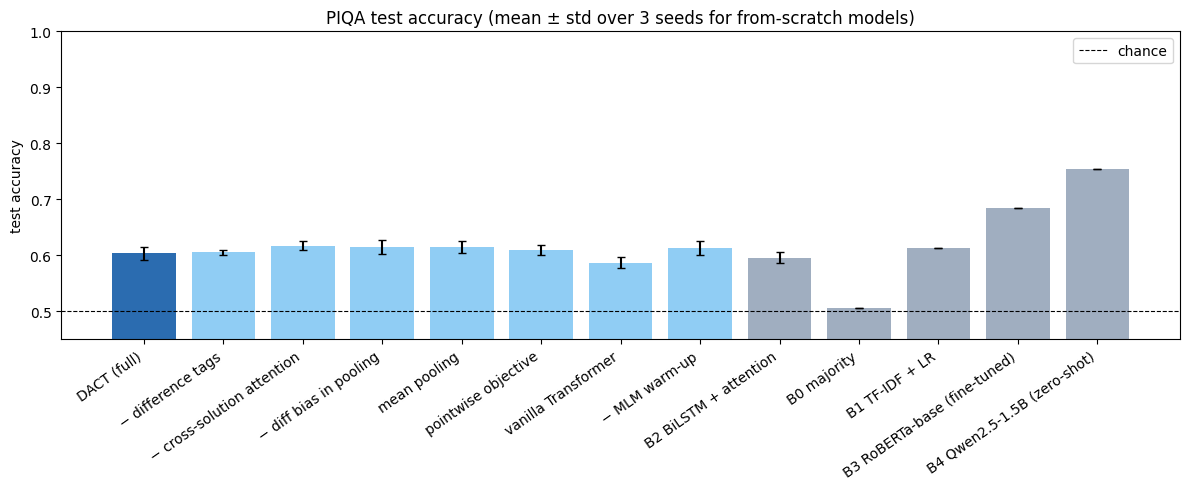

In [ ]:
order = ["DACT (full)"] + list(ABLATIONS) + ["B2 BiLSTM + attention"] + list(BASE)
R = RESULTS.set_index("model").loc[order]
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2b6cb0"] + ["#90cdf4"] * len(ABLATIONS) + ["#a0aec0"] * (1 + len(BASE))
ax.bar(range(len(R)), R["test acc"], yerr=R["test std"].fillna(0), color=colors, capsize=3)
ax.axhline(0.5, ls="--", c="k", lw=0.8, label="chance")
ax.set_xticks(range(len(R))); ax.set_xticklabels(R.index, rotation=35, ha="right")
ax.set_ylabel("test accuracy"); ax.set_ylim(0.45, 1.0); ax.legend()
ax.set_title("PIQA test accuracy (mean ± std over 3 seeds for from-scratch models)")
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "results", "test_accuracy.png"), dpi=120); plt.show()

### Where do DACT and the baselines disagree? (error overlap)
Accuracy alone cannot tell whether DACT and TF-IDF + LR get the *same* items right. For each pair we count the test items both / only one / neither model answer correctly (representative runs, chosen on validation). A high *oracle* accuracy (right if either model is right) compared with both models means they rely on different cues; an oracle close to the better model means one model's knowledge is essentially a subset of the other's.

In [ ]:
PAIRS = {"B1 TF-IDF + LR": BASE["B1 TF-IDF + LR"]["test_pred"],
         "B2 BiLSTM + attention": EXP["B2 BiLSTM + attention"]["test_preds"]["pred"],
         "vanilla Transformer": EXP["vanilla Transformer"]["test_preds"]["pred"],
         "B3 RoBERTa-base (fine-tuned)": BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"]}
OVERLAP = pd.DataFrame({name: error_overlap(ref, pred, yte) for name, pred in PAIRS.items()}).T
OVERLAP.columns = ["both correct", "only DACT", "only other", "both wrong", "agreement", "oracle"]
OVERLAP.to_csv(os.path.join(CFG.out_dir, "results", "error_overlap.csv"))
display(OVERLAP.round(3))

> ⚠️ **Update after re-running (revision 2).** The numbers in the discussion below come from the first A100 run. Revision 2 changed the truncation of over-long solutions, added the *diff-bias prior 0* ablation, 3 RoBERTa seeds, the error-overlap analysis and the attention controls. After `Run all`, copy the new values from the outputs above into this discussion, then delete this note.

### Quantitative discussion

**Main comparison (test accuracy, mean ± std over 3 seeds for trained-from-scratch models).**

| Model | Val | Test |
|---|---|---|
| **DACT (ours)** | **60.1 ± 0.7** | **60.4 ± 1.2** |
| Vanilla Transformer (same budget, no DACT components) | 57.9 ± 0.9 | 58.7 ± 0.9 |
| B2 BiLSTM + attention | 59.6 ± 1.2 | 59.5 ± 1.0 |
| B1 TF-IDF + logistic regression | 59.2 | 61.2 |
| B3 RoBERTa-base, fine-tuned | 70.0 | 68.5 |
| B4 Qwen2.5-1.5B, zero-shot | 78.1 | 75.4 |

1. **DACT is the best from-scratch neural model.** It beats the vanilla Transformer by +2.2 points on validation and +1.7 on test, and the BiLSTM by +0.5 / +0.8. The gain over the vanilla Transformer is the combined effect of our PIQA-specific changes. It holds on both splits in the mean, and on validation all three vanilla seeds are below all three DACT seeds. It is still modest.
2. **It is not a large gain, and we do not over-claim it.** With 1,838 test items the 95 % CI of a single model spans about ±2.3 points, and seed std is about 1 point. McNemar tests between DACT's representative run and B1/B2 are not significant (p = 0.12 and 0.42). One caveat: the representative DACT run is the seed with the best *validation* accuracy (seed 44), which happens to be DACT's weakest seed on test (59.0 % vs 60.9 % and 61.2 %). We keep it because choosing a seed by test accuracy would break the test-set protocol.
3. **Shallow lexical cues are a strong baseline on PIQA.** TF-IDF + LR on the *difference* of the two solutions reaches 59.2 % (val) and 61.2 % (test). With only 14.5k training items and no external text, a large share of the learnable signal is which words tend to appear in plausible solutions (*baby wipes* vs *index cards*). Real physical reasoning needs world knowledge that cannot be learned from this data alone.
4. **Pretrained knowledge is the main bottleneck.** Fine-tuned RoBERTa gains about 8 points and a zero-shot 1.5B-parameter LLM about 15 points over every from-scratch model, without any architectural specialisation. This agrees with PIQA being designed to test physical commonsense rather than reading skill.

**Ablations** (Δ vs full DACT; the validation split is the one we used for decisions):

| Ablation | Val Δ | Test Δ |
|---|---|---|
| − difference tags | −1.1 | +0.1 |
| − MLM warm-up | −1.0 | +1.0 |
| − diff bias in pooling | −0.7 | +1.1 |
| mean pooling | −0.3 | +1.1 |
| − cross-solution attention | −0.0 | +1.4 |
| pointwise objective | −0.0 | +0.5 |
| **all DACT components removed (vanilla)** | **−2.2** | **−1.7** |

* On **validation**, every single-component ablation ties with or is worse than the full model. The difference tags and the MLM warm-up matter most (about −1 point each). Cross-solution attention and the pairwise objective show **no measurable individual contribution**.
* On **test**, most single-component ablations score 0.5-1.4 points *above* the full model. These gaps are about one seed-std and inside the CIs. They go the other way from validation, which points to noise from a validation split of 1.6k items rather than a real effect. We report them as observed and did not change the model afterwards, because the test split must not drive design decisions.
* Only removing *all* components hurts consistently on both splits. Our reading is that the components are **partly redundant**: the difference tags, the diff-biased pooling and the cross-solution attention all give the model the same information, namely where the options differ. Any one of them recovers most of the benefit, so removing a single one costs little. The honest conclusion is that *making the difference between the options explicit* helps, and none of the individual mechanisms is indispensable.

## 3.3 Qualitative analysis of attention
We analyse the best-validation-seed checkpoint of the full DACT. For each selected test item the figure shows:
1. **top row**: the difference-guided pooling weights over each option's tokens (the vector the scorer sees);
2. **bottom-left**: contrastive cross-solution attention from option-1 tokens (rows) to option-2 tokens (columns), averaged over heads;
3. **bottom-right**: last-encoder-layer attention from each option's tokens to the goal tokens.

Tokens that differ between the two options are shown in **bold red**. Cases: the two most confident correct predictions, the two most confident errors, and the most uncertain item.

In [ ]:
best_run = max(EXP["DACT (full)"]["runs"], key=lambda r: r["val_acc"])
DACT_BEST = DACT(BEST_CFG, DATA["vocab_size"]).to(DEVICE)
DACT_BEST.load_state_dict(torch.load(best_run["ckpt"], map_location=DEVICE))
DACT_BEST.eval()
tp = EXP["DACT (full)"]["test_preds"]
CASES = select_cases(tp["pred"], tp["prob"], tp["label"], k=2)
print(CASES)
os.makedirs(os.path.join(CFG.out_dir, "figures"), exist_ok=True)

{'confident_correct': [804, 280], 'confident_wrong': [660, 708], 'uncertain': [1433, 918]}


--- confident_correct | test item 804 | gold = option 1
  goal: Remove dust residue from chalk boards.
  sol1: Wipe down with baby wipes.
  sol2: Wipe down with index cards.


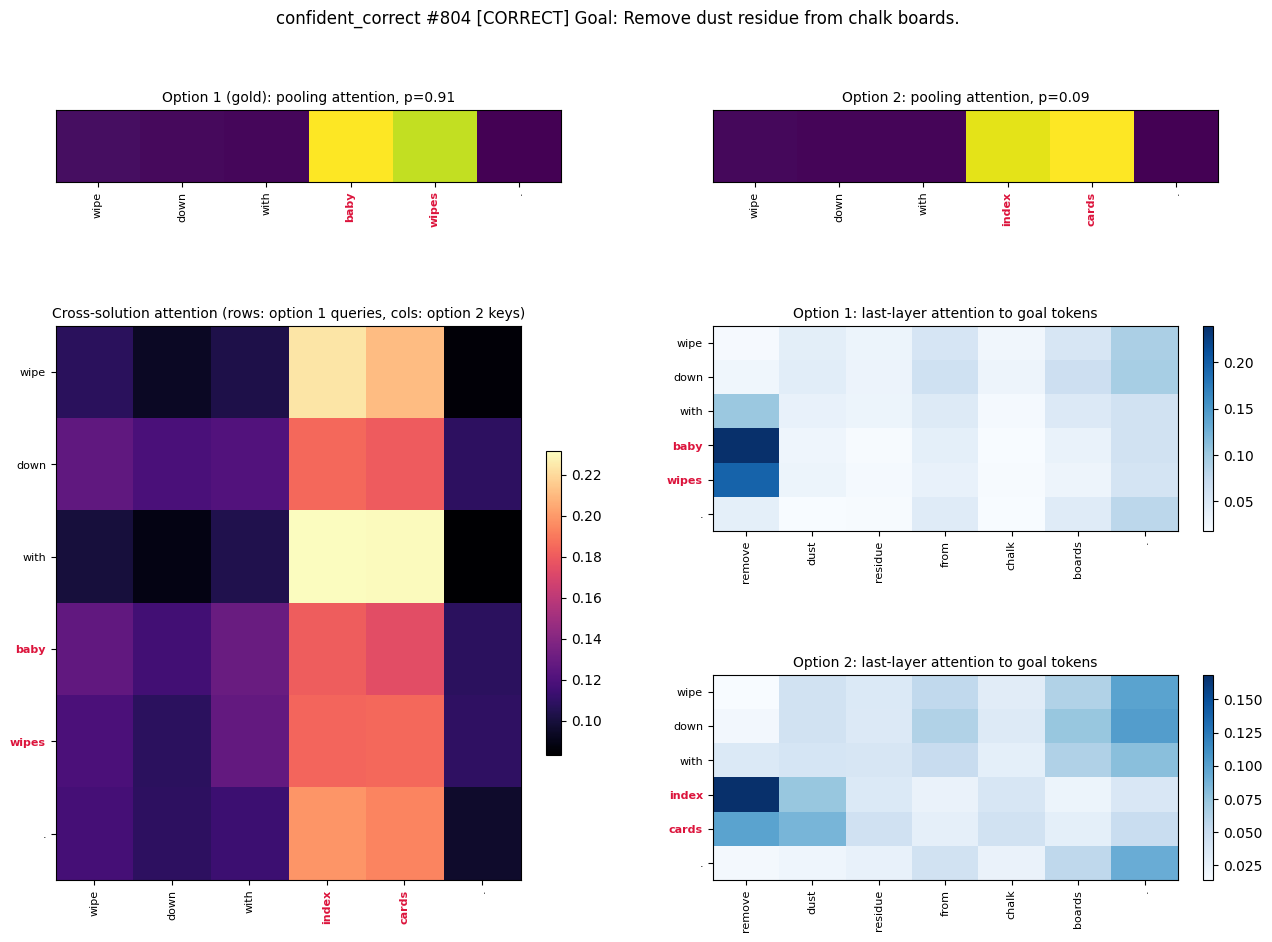

--- confident_correct | test item 280 | gold = option 1
  goal: Clean dirty cup coaster.
  sol1: Wipe with baby wipes.
  sol2: Wipe with tissue paper.


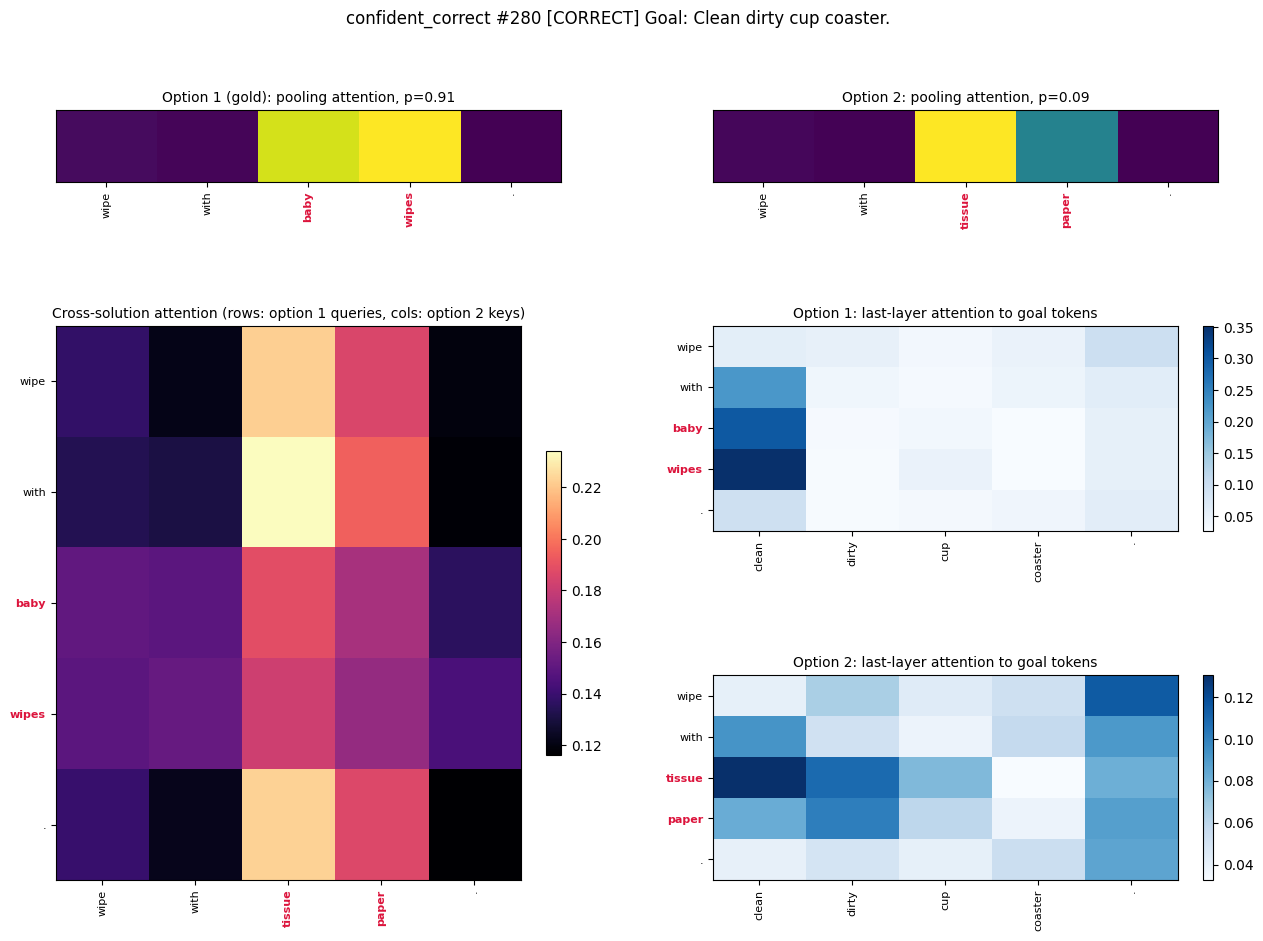

--- confident_wrong | test item 660 | gold = option 1
  goal: To store food without a refrigerator,
  sol1: put the food inside of a cooler filled with ice.
  sol2: put the food inside of a small chest of water.


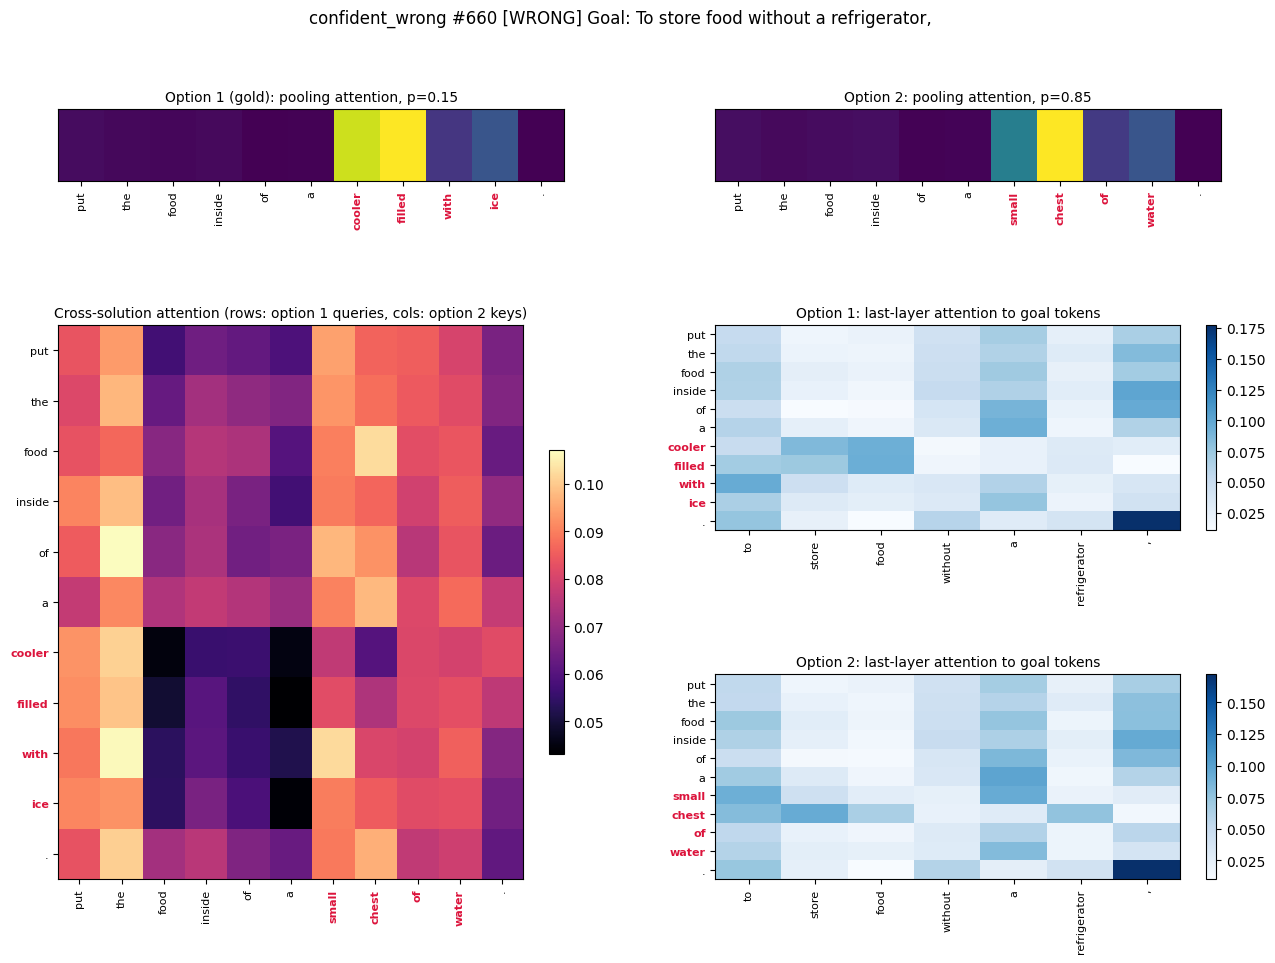

--- confident_wrong | test item 708 | gold = option 2
  goal: To make a ball of aluminum foil,
  sol1: take a sheet of aluminum foil and fold it in half
  sol2: take a sheet of aluminum foil and crinkle it into a ball.


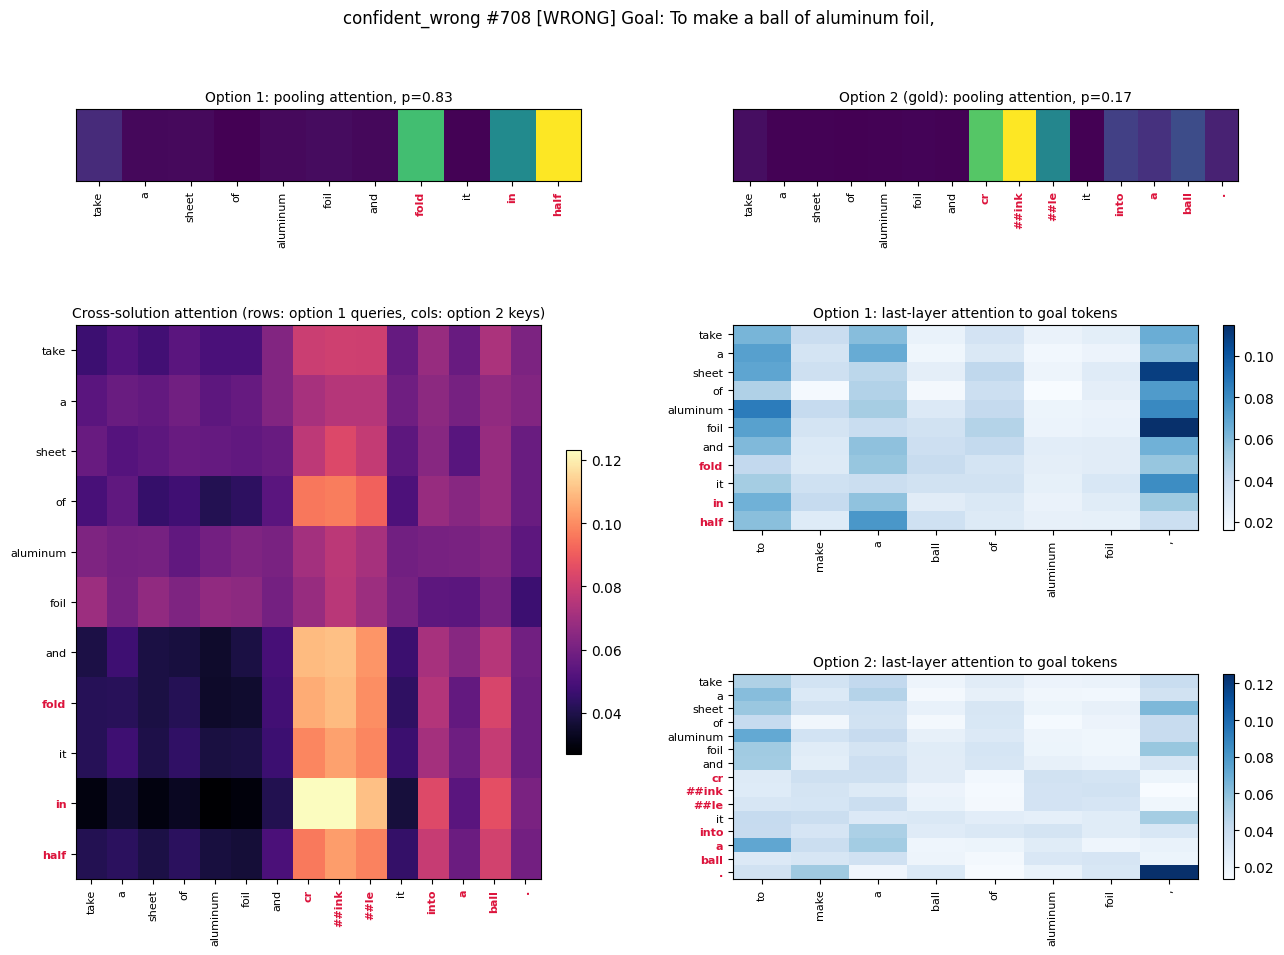

In [ ]:
for kind in ("confident_correct", "confident_wrong"):
    for i in CASES[kind]:
        r = DATA["test"][i]
        print(f"--- {kind} | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
        plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"{kind} #{i}",
                            save_path=os.path.join(CFG.out_dir, "figures", f"{kind}_{i}.png"))

--- uncertain | test item 1433 | gold = option 2
  goal: How to make a Wild Blackberry cobbler at home.
  sol1: Wash 4 cups fresh or frozen wild blackberries toss berries with 3 tablespoons Lemon juice. Use Pillsbury Cinnamon roll(tube type) from refrigerated section in the market, with rolling pin, roll to less than 1/2 inch thick. Line the base of a deep metal baking pan/dish with the dough. Reserve approx. 1/3 of dough for cover. (You will place this on top after you finish preparing the filling.) Place blackberries in dish atop the roll dough. Sprinkle 1 cup ground coffee, 2 tbs. Brown sugar 1 tablespoons cinnamon, 1/2 cup butter (In small pieces), on top. Sprinkle 1/2 tablespoon of salt atop. Place crust over everything. Bake in the oven at 375 for 40 min. Remove from oven when crust brown and pie is bubbly. Enjoy.
  sol2: Wash 4 cups fresh or frozen wild blackberries toss berries with 3 tablespoons Lemon juice. Use Pillsbury Cinnamon roll(tube type) from refrigerated section in t

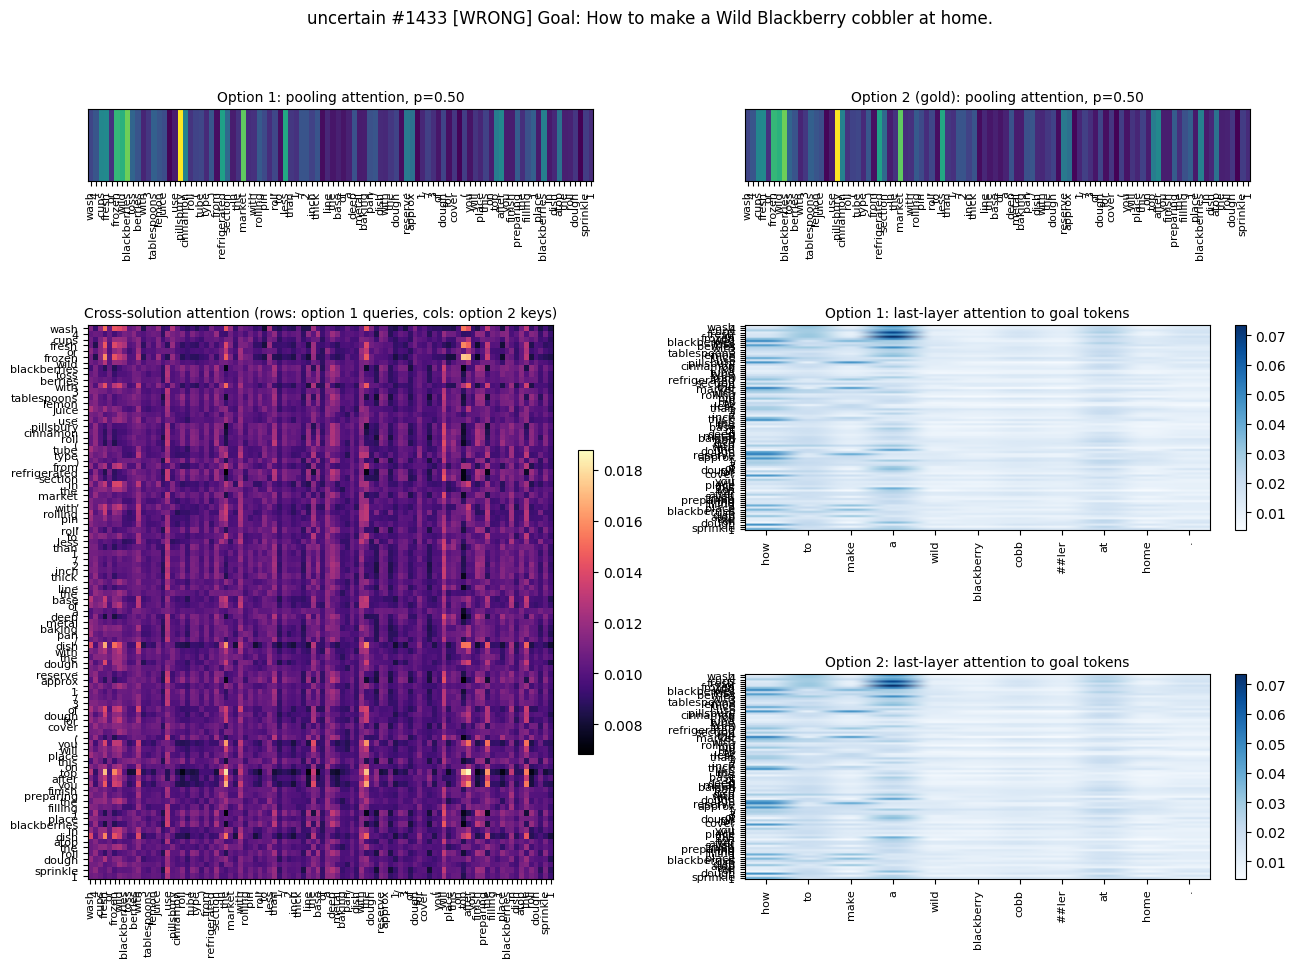

In [ ]:
i = CASES["uncertain"][0]
r = DATA["test"][i]
print(f"--- uncertain | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
_ = plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"uncertain #{i}",
                        save_path=os.path.join(CFG.out_dir, "figures", f"uncertain_{i}.png"))

### Does attention focus on the differing tokens, and does that relate to correctness?
For every test item we measure the share of pooling attention that falls on difference-tagged tokens and compare it with the share those tokens would get under uniform attention, separately for correct and wrong predictions.

**Control (revision 2).** The pooling bias for differing tokens is *initialised* at 1.0, so part of this focus is built in before any training. We therefore also measure the mass (a) of the same trained model with the tag bias set to 0, i.e. the focus coming only from the learned token representations, and (b) of an untrained model, i.e. the focus produced by the initial bias alone. The *diff-bias prior 0* ablation (Step 3) is the matching training-time control.

In [ ]:
from scipy.stats import mannwhitneyu
test_loader = make_loader(DATA["test_ds"], BEST_CFG, False, DEVICE)
mass, correct = diff_attention_mass(DACT_BEST, test_loader, DEVICE)
uniform = diff_token_share(test_loader)
print(f"learned pooling tag bias [other, shared, diff]: {DACT_BEST.pool.tag_bias.detach().cpu().numpy().round(3)}")
print(f"mean attention mass on differing tokens: {mass.mean():.3f} (uniform-attention reference {uniform.mean():.3f})")
print(f"  correct predictions: {mass[correct].mean():.3f} | wrong predictions: {mass[~correct].mean():.3f}")
print("  Mann-Whitney U (correct vs wrong): p = %.4g" % mannwhitneyu(mass[correct], mass[~correct]).pvalue)
CONTROLS = diff_attention_controls(DACT_BEST, BEST_CFG, DATA["vocab_size"], test_loader, DEVICE)
CONTROLS["uniform attention (reference)"] = float(uniform.mean())
display(pd.Series(CONTROLS, name="mean pooling mass on differing tokens").round(3).to_frame())
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(mass[correct], bins=30, alpha=0.6, density=True, label="correct")
ax.hist(mass[~correct], bins=30, alpha=0.6, density=True, label="wrong")
ax.axvline(uniform.mean(), c="k", ls="--", lw=1, label="uniform reference")
ax.set_xlabel("pooling attention mass on differing tokens"); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "figures", "diff_attention_mass.png"), dpi=120); plt.show()

> ⚠️ **Update after re-running (revision 2).** The numbers in the discussion below come from the first A100 run. Revision 2 changed the truncation of over-long solutions, added the *diff-bias prior 0* ablation, 3 RoBERTa seeds, the error-overlap analysis and the attention controls. After `Run all`, copy the new values from the outputs above into this discussion, then delete this note.

### Qualitative discussion

**What the attention does in general.** The learned pooling bias for difference-tagged tokens went from its initial value 1.0 to about 1.02 in training, while the bias for shared tokens stayed near 0. On average DACT puts **64 % of its pooling attention on the differing tokens, although they make up only 25 % of solution tokens** (uniform reference, dashed line). Because the bias barely moved from its initial value, this concentration could be largely built in by the initialisation rather than learned. The controls above separate the two: the trained model with the bias removed shows how much focus the learned representations produce on their own, and the untrained model shows what the bias alone produces. The attention mass on differing tokens is almost the same for correct (63.0 %) and wrong (64.7 %) predictions (Mann-Whitney p = 0.08). **Looking at the right tokens is therefore necessary but not sufficient.** Errors come from judging those tokens wrongly, not from looking elsewhere.

**Success: "Remove dust residue from chalk boards", *baby wipes* ✓ vs *index cards* (p = 0.91).** Pooling attention sits almost entirely on *baby wipes* / *index cards*. In the last encoder layer, *baby* and *wipes* attend strongly to the goal verb *remove*, so the differing tokens are read in the context of the action. The cross-solution map shows every option-1 token attending to *index cards*: the comparison centres on the substituted object. The second success (*Clean dirty cup coaster*: *baby wipes* ✓ vs *tissue paper*, p = 0.91) has the same pattern: pooling on the substituted nouns, *baby*/*wipes* attending to *clean*, and cross-attention from option 1 concentrated on *tissue paper*. Both successes reuse a **lexical prior from the training split**. In training items, *baby wipe(s)* appears only in the correct option 26 times and only in the wrong option 5 times, while *tissue paper* appears only in the correct option 3 times and only in the wrong option 24 times. The model is confident because it has seen these phrases before, not because it reasons about absorbency. This is the association a from-scratch model can learn from 14.5k items, and it also explains why TF-IDF + LR does well.

**Failure 1: "To store food without a refrigerator", *cooler filled with ice* (gold) vs *small chest of water* (p = 0.85 for the wrong option).** Pooling again concentrates on the differing span (*cooler filled* / *small chest*). However, *ice*, the word that decides the item, gets relatively little pooling weight. The cross-solution attention from *cooler … ice* does not line up with *chest … water*; it spreads over the shared words *put the* and over *small*. The lexical prior also works against the model here: in training, *cooler* appears only in the wrong option 7 times and only in the correct option 2 times. The goal token *refrigerator*, which ties the goal to temperature, gets almost no attention from either option. The model finds the differing phrase but lacks the physical knowledge that ice keeps food cold. It falls back on a misleading word statistic.

**Failure 2: "To make a ball of aluminum foil", *fold it in half* vs *crinkle it into a ball* (gold) (p = 0.83 for the wrong option).** The pooling focuses on *fold … half* and on *cr ##ink ##le*, and the cross-solution attention aligns option 1's *in* / *fold* with *cr ##ink ##le*. The model therefore correctly identifies *fold in half ↔ crinkle into a ball* as the substitution. But *crinkle* occurs in only 2 training items and is split into three sub-word pieces, so its representation is weak. The gold option also repeats the goal words *a ball*, a strong cue a human would use, but the solution-to-goal attention does not link *ball* to the goal's *ball*. The model apparently prefers the common, "safe" instruction *fold it in half*. This shows two limits of training from scratch: a weak representation of rare words, and no reliable goal-solution matching learned from 14.5k items.

**Uncertain case: blackberry cobbler, *ground coffee* vs *granulated sugar* (gold) (p = 0.50).** The two 162-token options differ only at BPE positions 97-98, **just past our 96-token truncation limit**. After truncation both inputs are identical (no red tokens; both end at *sprinkle 1*), so every attention map and both scores are identical. The model does not fail here through reasoning: preprocessing removes the evidence. This long-tail case (about 1-2 % of solutions exceed 96 tokens) points to an easy improvement: **truncate around the difference span** (keep a window centred on the differing tokens) instead of keeping the prefix.

**Summary.** The attention maps confirm that DACT's components work as designed. The decision is concentrated on the differing words, and the cross-solution attention aligns substituted phrases. The failures show that DACT's limit is mostly **knowledge, not focus**. It finds the decisive tokens but judges them with word statistics from the training split (*baby wipes* good, *cooler* bad) instead of physical knowledge, which only pretraining provides (B3/B4). The one clear focus failure (the cobbler item) is caused by prefix truncation, and difference-centred truncation would fix it.

In [ ]:
# Persist logs, results and figures to Google Drive (checkpoints excluded to save space)
import shutil
if not SMOKE and os.path.isdir("/content/drive/MyDrive"):
    dst = "/content/drive/MyDrive/Group69/outputs"
    shutil.copytree(CFG.out_dir, dst, dirs_exist_ok=True, ignore=shutil.ignore_patterns("checkpoints"))
    print("copied to", dst)
print(sorted(os.listdir(os.path.join(CFG.out_dir, "logs")))[:10], "...")

['B3_roberta-base_seed42.jsonl', 'abl0_seed42.jsonl', 'abl0_seed42_mlm.jsonl', 'abl0_seed43.jsonl', 'abl0_seed43_mlm.jsonl', 'abl0_seed44.jsonl', 'abl0_seed44_mlm.jsonl', 'abl1_seed42.jsonl', 'abl1_seed42_mlm.jsonl', 'abl1_seed43.jsonl'] ...


# References
Full BibTeX entries are in `references.bib` (used for the report).

* Bisk, Y., Zellers, R., Le Bras, R., Gao, J., & Choi, Y. (2020). PIQA: Reasoning about Physical Commonsense in Natural Language. *AAAI*.
* Vaswani, A. et al. (2017). Attention Is All You Need. *NeurIPS*.
* Xiong, R. et al. (2020). On Layer Normalization in the Transformer Architecture. *ICML* (pre-LN encoder blocks).
* Chen, Q. et al. (2017). Enhanced LSTM for Natural Language Inference. *ACL* (ESIM `[h; c; h−c; h⊙c]` fusion used in the cross-solution block).
* Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural Machine Translation by Jointly Learning to Align and Translate. *ICLR* (additive attention pooling).
* Devlin, J. et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL* (masked-LM objective of the warm-up).
* Liu, Y. et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. *arXiv:1907.11692* (baseline B3).
* Qwen Team (2024). Qwen2.5 Technical Report. *arXiv:2412.15115* (baseline B4).
* Sennrich, R., Haddow, B., & Birch, A. (2016). Neural Machine Translation of Rare Words with Subword Units. *ACL* (BPE tokenizer).
* Gururangan, S. et al. (2018). Annotation Artifacts in Natural Language Inference Data. *NAACL* (lexical shortcuts, cf. the TF-IDF baseline).
* Jain, S., & Wallace, B. C. (2019). Attention is not Explanation. *NAACL*; Wiegreffe, S., & Pinter, Y. (2019). Attention is not not Explanation. *EMNLP* (limits of reading attention maps).
* McNemar, Q. (1947). Note on the sampling error of the difference between correlated proportions or percentages. *Psychometrika*; Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*.
* Dror, R. et al. (2018). The Hitchhiker's Guide to Testing Statistical Significance in Natural Language Processing. *ACL*.